In [8]:
!pip install seaborn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator, num2date
from matplotlib.ticker import FuncFormatter
import datetime
import os
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 20,10
import warnings
warnings.filterwarnings("ignore")

In [9]:
os.chdir("D:\\data analytics\\ML PROJECTS\\Cohort 140_Day 45 Projects\\Project -Sales Department")

In [10]:
sales_dep=pd.read_csv('train.csv')
display(sales_dep.head())

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [12]:
# Display the shape (number of rows and columns)
display (sales_dep.shape)


(1017209, 9)

In [14]:
sales_dep.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [15]:
sales_dep.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [16]:
# import store csv file data

store_data=pd.read_csv('store.csv')
store_data.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [18]:
store_data.shape

(1115, 10)

In [19]:
store_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [20]:
store_data.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [22]:
#EXPLORE SALES DATA

sales_dep.isna().sum()

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

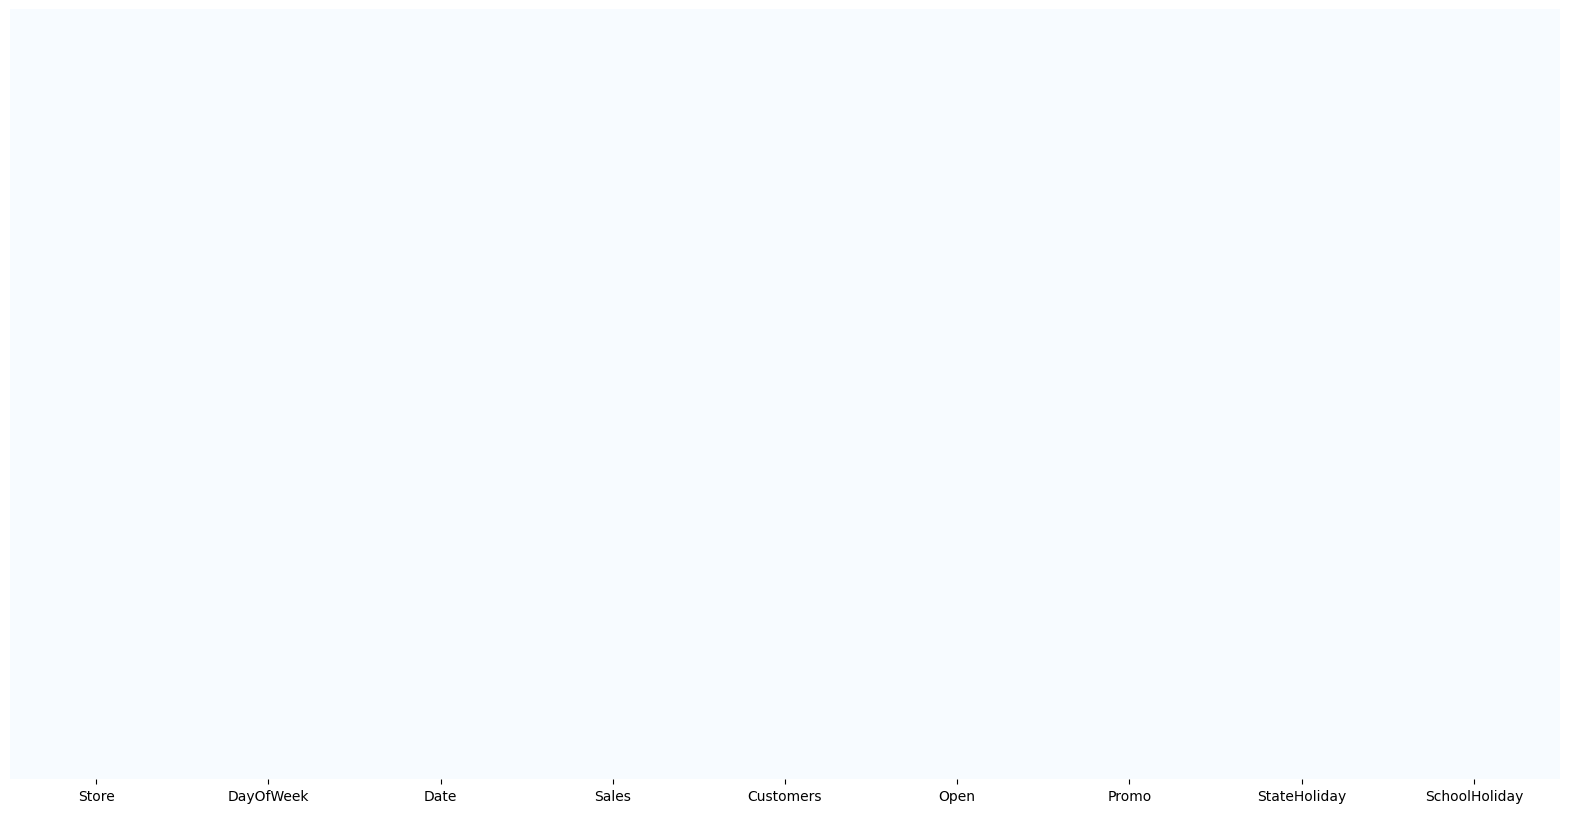

In [23]:
#Plot Missing Data – Heat Map to check missing data, in this case no graph created , no missing data

sns.heatmap(sales_dep.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()


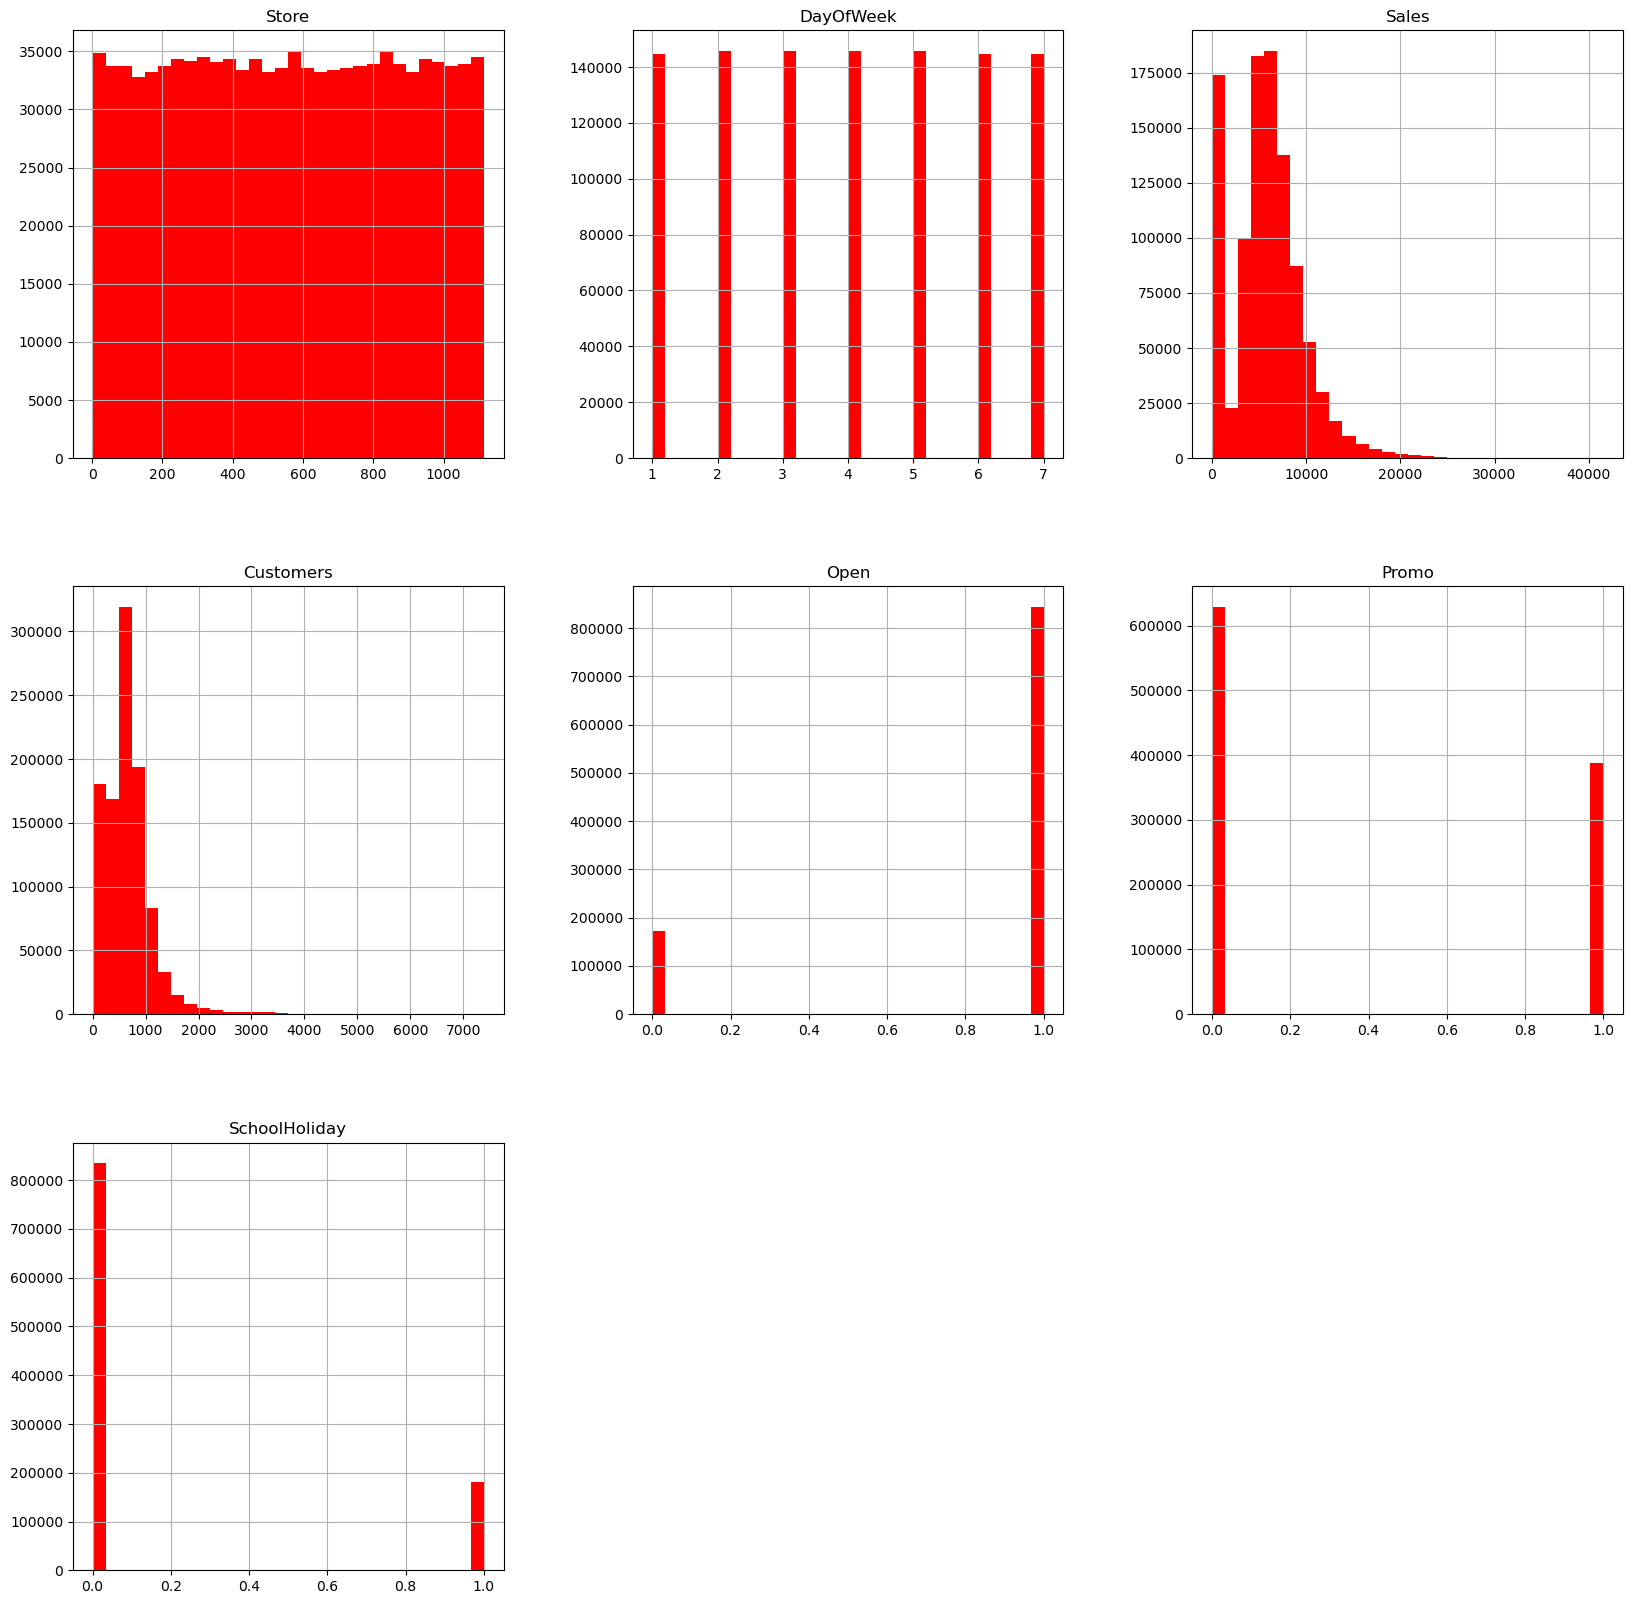

In [24]:
# Create Histogram of sales data. Histogram created for numeric columns
sales_dep.hist(bins = 30, figsize = (20,20), color = 'r')
plt.show()


In [25]:
# Maximum number of customers in a store in a day.

display (sales_dep['Customers'].max())


np.int64(7388)

In [26]:
# Number of stores open or closed 

closed_train_df= sales_dep[sales_dep['Open'] == 0]
open_train_df= sales_dep[sales_dep['Open'] == 1]


In [28]:
# Count the number of stores that are open and closed

print("Total =", len(sales_dep))
print("Number of closed stores =", len(closed_train_df))
print("Number of open stores =", len(open_train_df))


Total = 1017209
Number of closed stores = 172817
Number of open stores = 844392


In [29]:
# # Only keep open stores and remove closed stores, since there no sales for closed stores, sales are 0 for closed store

sales_dep = sales_dep[sales_dep['Open'] == 1]


In [30]:
# Display the data after removing closed store data  

display(sales_dep)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,1,0,a,1
1016827,733,2,2013-01-01,10765,2377,1,0,a,1
1016863,769,2,2013-01-01,5035,1248,1,0,a,1
1017042,948,2,2013-01-01,4491,1039,1,0,a,1


In [31]:
#Drop the open column since it has no meaning now

sales_dep.drop(['Open'], axis=1, inplace=True)
display(sales_dep)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1
...,...,...,...,...,...,...,...,...
1016776,682,2,2013-01-01,3375,566,0,a,1
1016827,733,2,2013-01-01,10765,2377,0,a,1
1016863,769,2,2013-01-01,5035,1248,0,a,1
1017042,948,2,2013-01-01,4491,1039,0,a,1


In [32]:
# Describe the data 
display (sales_dep.describe())


,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


In [34]:
# EXPLORE STORES INFORMATION DATA
#Check missing data  

display (store_data.isna().sum())


Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

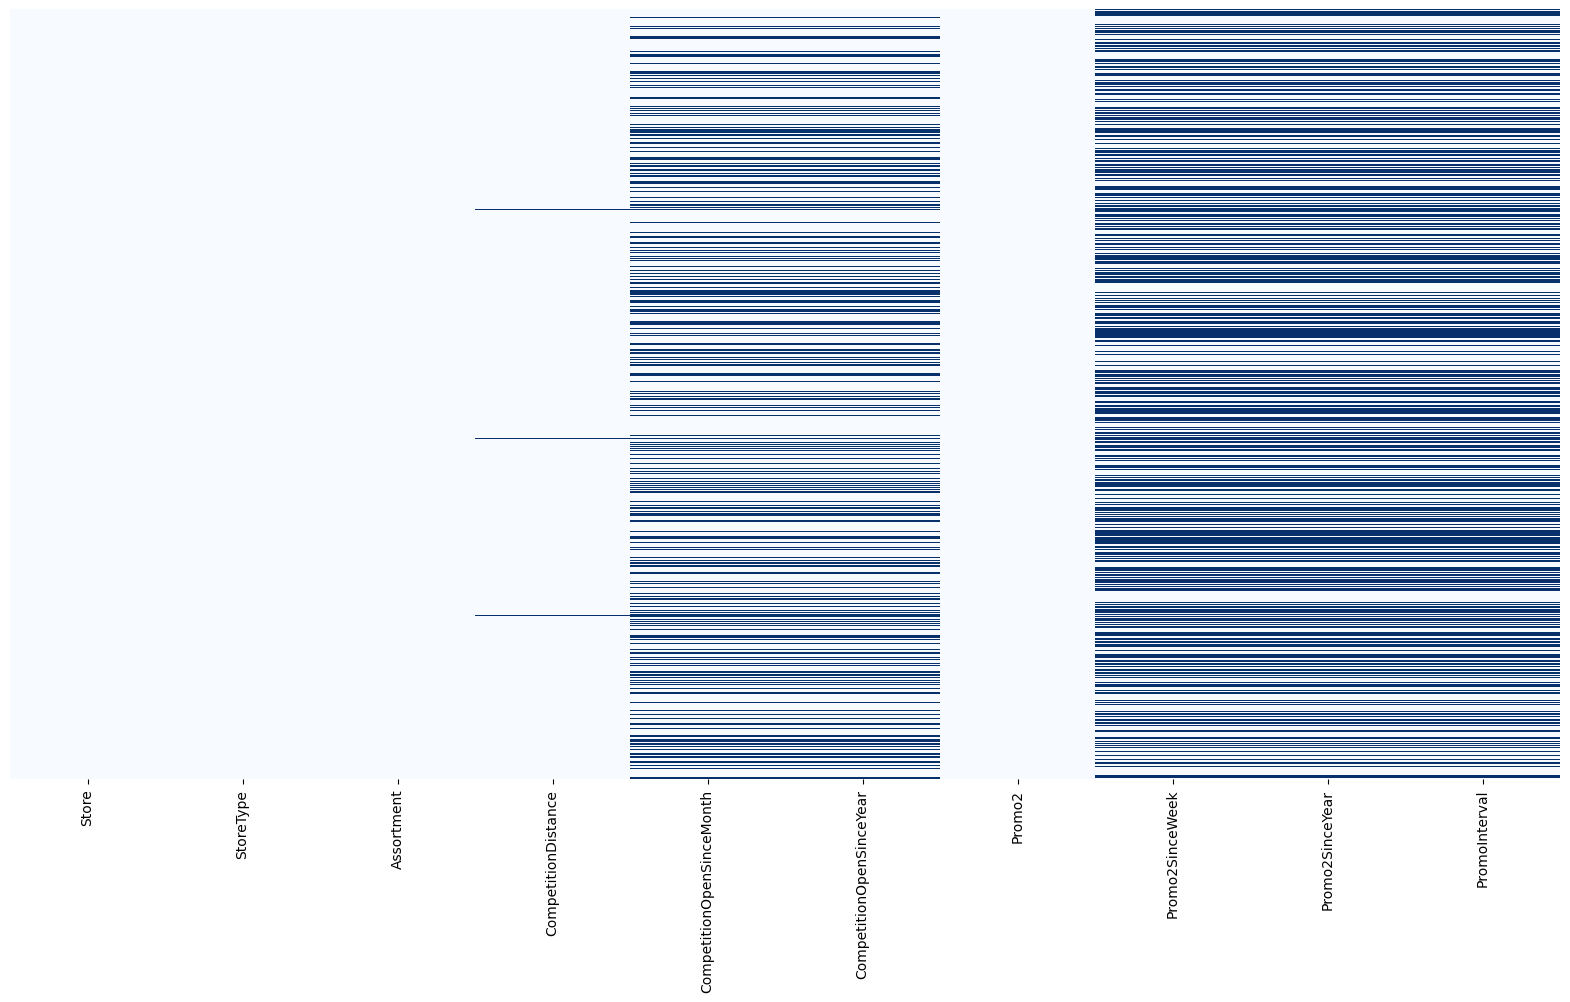

In [35]:
#Heat Map to check missing Data   
# Check missing data in the store information data frame

sns.heatmap(store_data.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()


In [36]:
# Display records with missing values in the 'CompetitionDistance' column
# Only 3 rows are missing 

display (store_data[store_data['CompetitionDistance'].isnull()])


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [37]:
#  Display records with missing values in the 'CompetitionOpenSinceMonth' column
# Many rows are missing = 354 (almost one third of the 1115 stores)

display (store_data[store_data['CompetitionOpenSinceMonth'].isnull()])


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [38]:
#Display all records with Promo2 = 0

display (store_data[ store_data['Promo2'] == 0])


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [39]:
# #  Display records with missing values in the column'CompetitionOpenSinceYear No of records 354' 

display (store_data[store_data['CompetitionOpenSinceYear'].isnull()])


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [41]:
# # There are 354 rows where 'CompetitionOpenSinceYear' and 'CompetitionOpenSinceMonth' is missing
# Update the following columns to zeros , if null

str_cols = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth']

for str in str_cols:
    store_data [str].fillna(0, inplace = True)



In [42]:
# Check for NULL values 
display (store_data.isna().sum())


Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          3
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [43]:
# There are 3 rows with 'competitionDistance' values missing, let's fill them up with with average values of the 'CompetitionDistance' column

store_data['CompetitionDistance'].fillna(store_data['CompetitionDistance'].mean(), inplace = True)


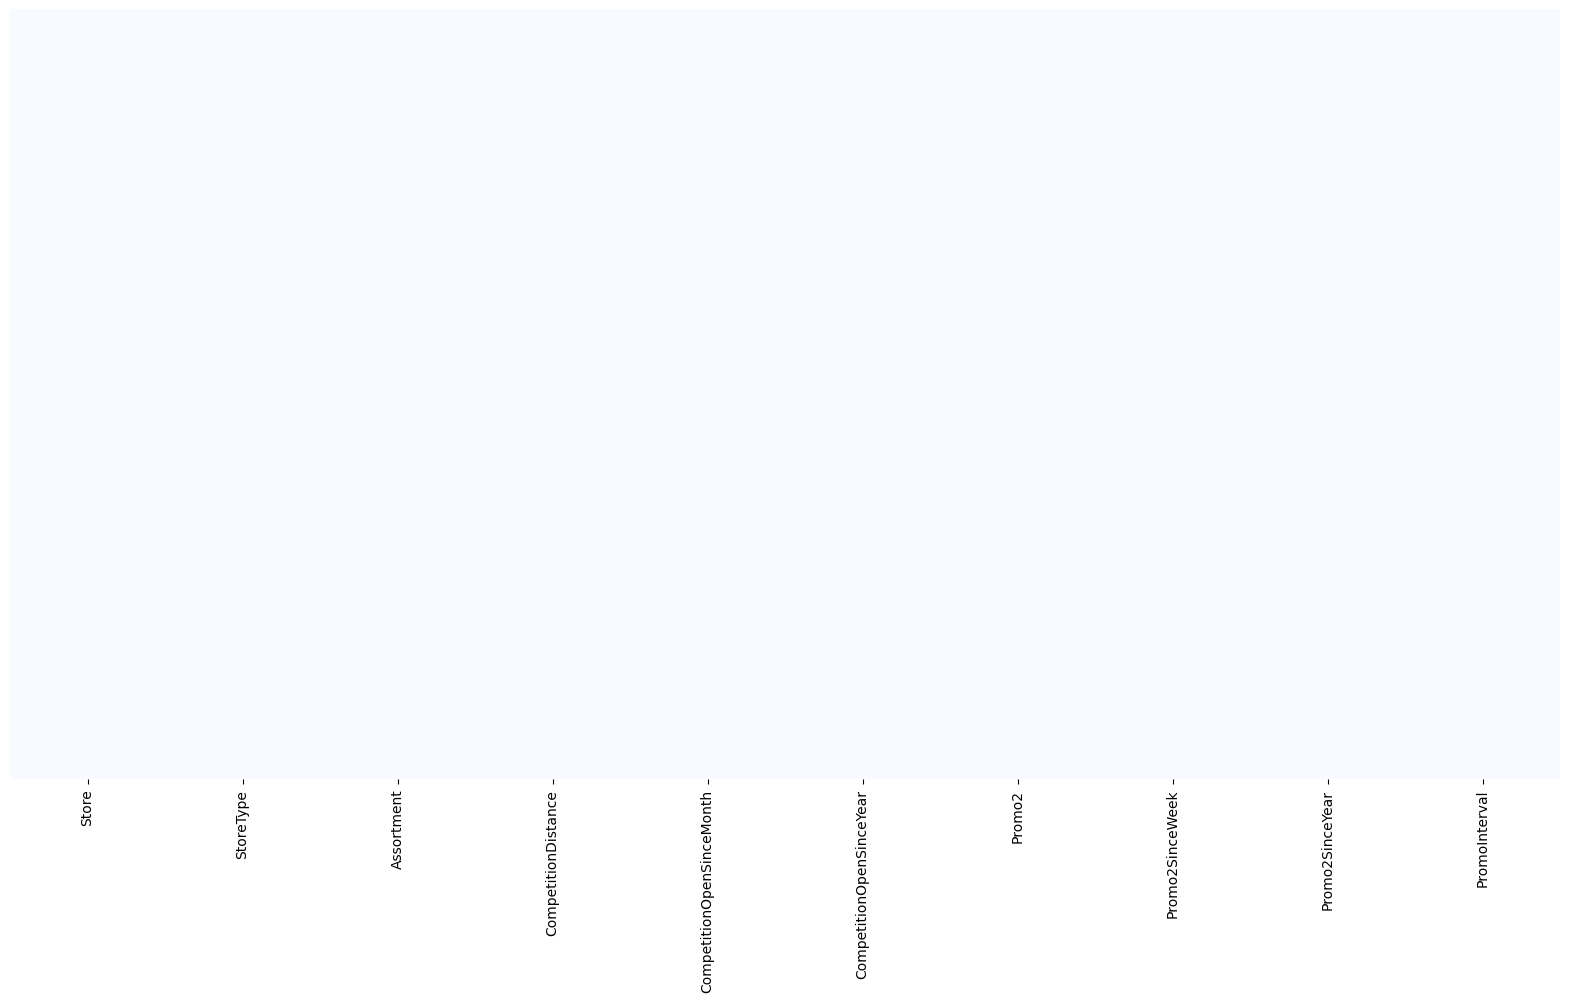

In [44]:
# Create heat map to check for NULL values 

sns.heatmap(store_data.isnull(), yticklabels = False, cbar = False, cmap="Blues")
plt.show()


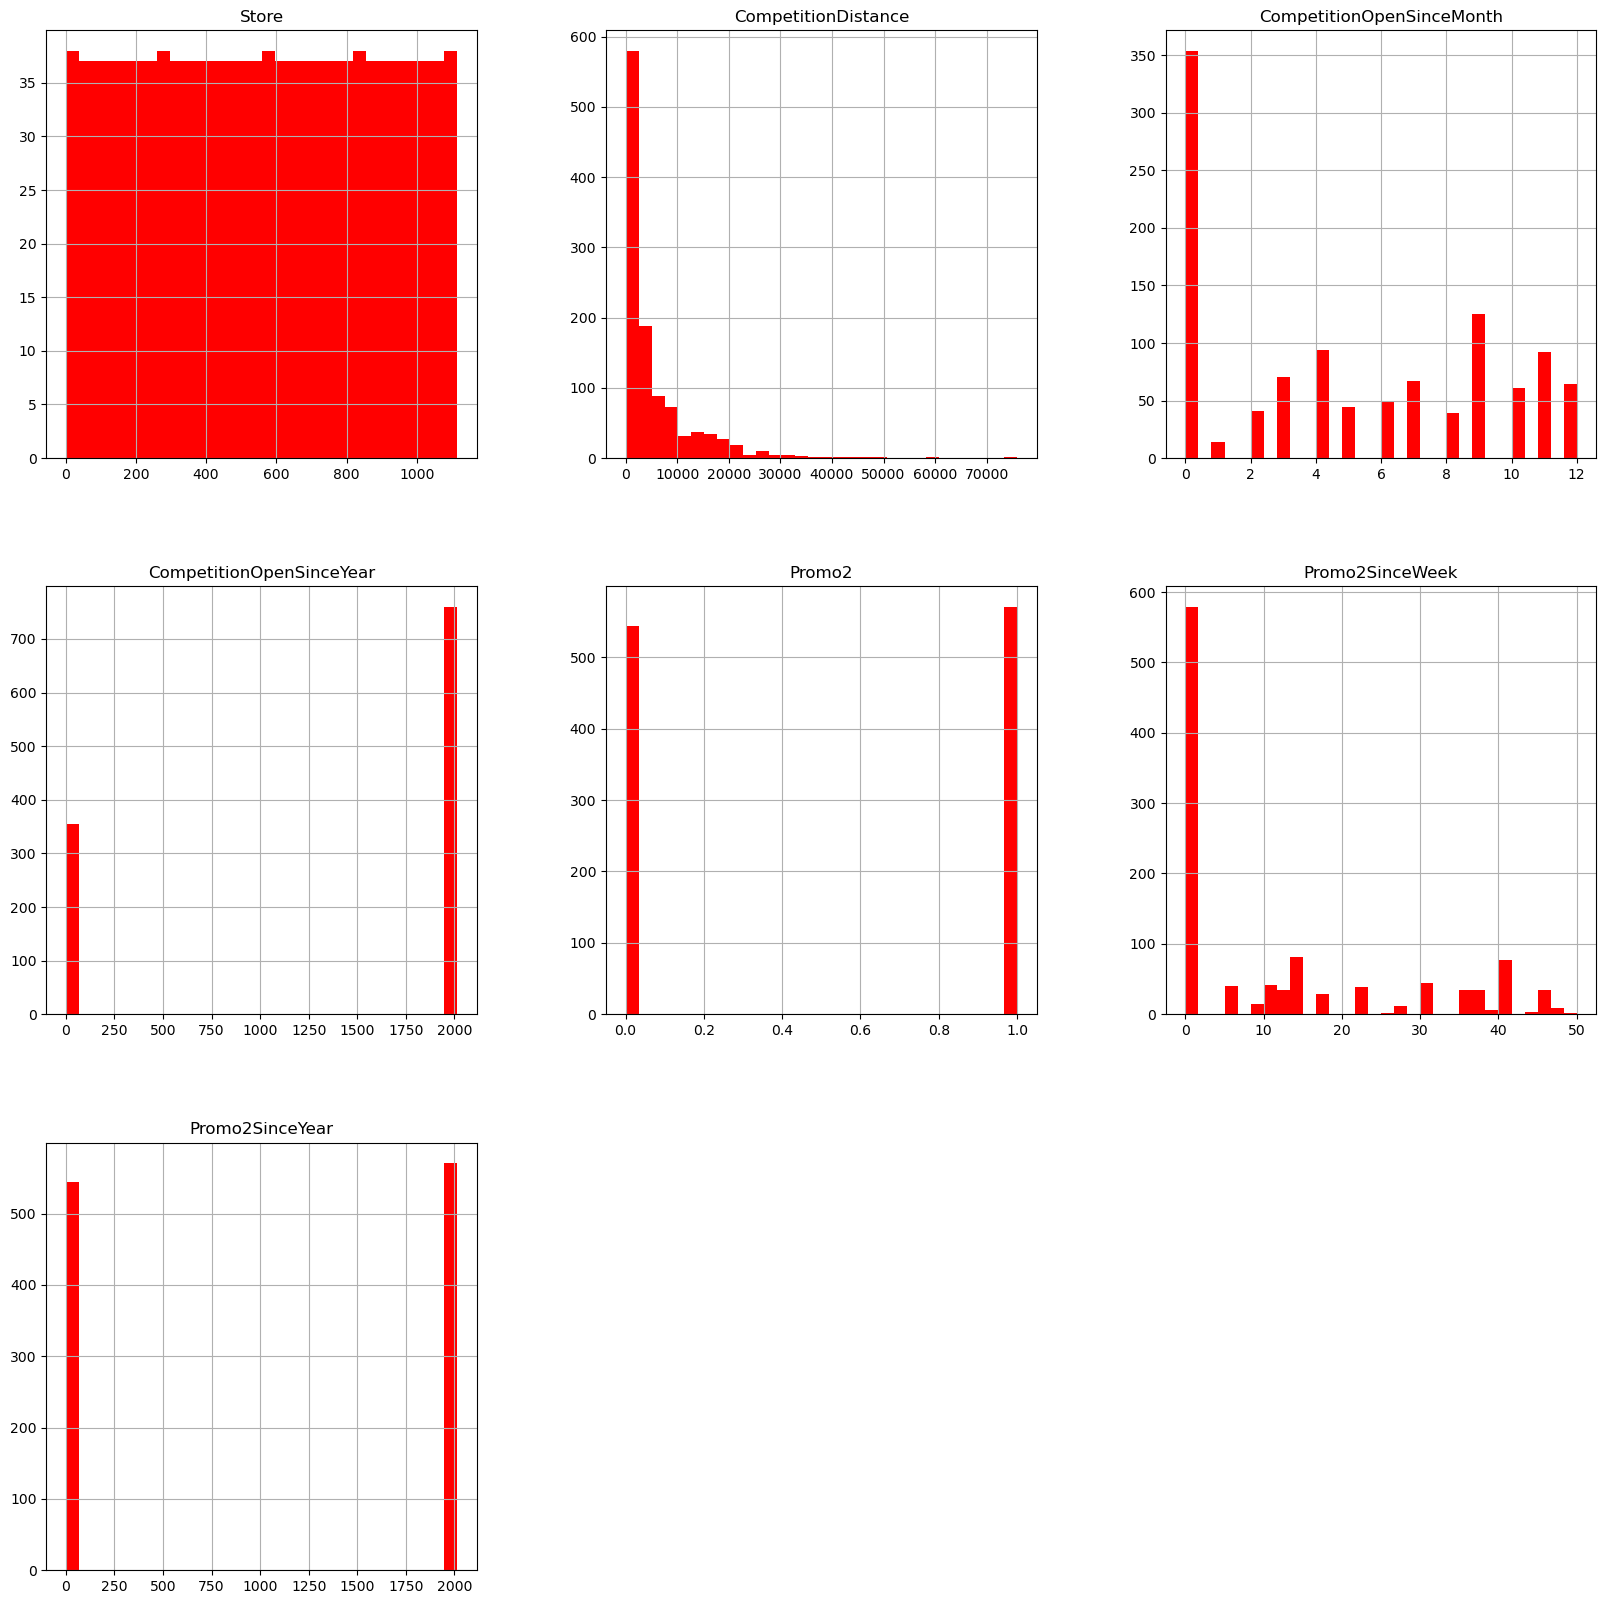

In [45]:
# Create histogram to View Data
store_data.hist(bins = 30, figsize = (20,20), color = 'r')
plt.show()


In [46]:
# EXPLORE MERGED DATASET

# Let's merge both data frames together based on 'store'

sales_train_all_df = pd.merge(sales_dep, store_data, how = 'inner', on = 'Store')


In [47]:
#Display Merged Data Frames 
# Create .csv file with merged data set 

sales_train_all_df.to_csv('merged_test.csv', index=False)


In [49]:
# Create corelation with Sales Columns 

correlations = sales_train_all_df.corr(numeric_only=True)['Sales'].sort_values()
print (correlations)


DayOfWeek                   -0.178736
Promo2SinceYear             -0.127621
Promo2                      -0.127596
Promo2SinceWeek             -0.058476
CompetitionDistance         -0.036343
CompetitionOpenSinceMonth   -0.018370
CompetitionOpenSinceYear     0.005266
Store                        0.007710
SchoolHoliday                0.038617
Promo                        0.368145
Customers                    0.823597
Sales                        1.000000
Name: Sales, dtype: float64


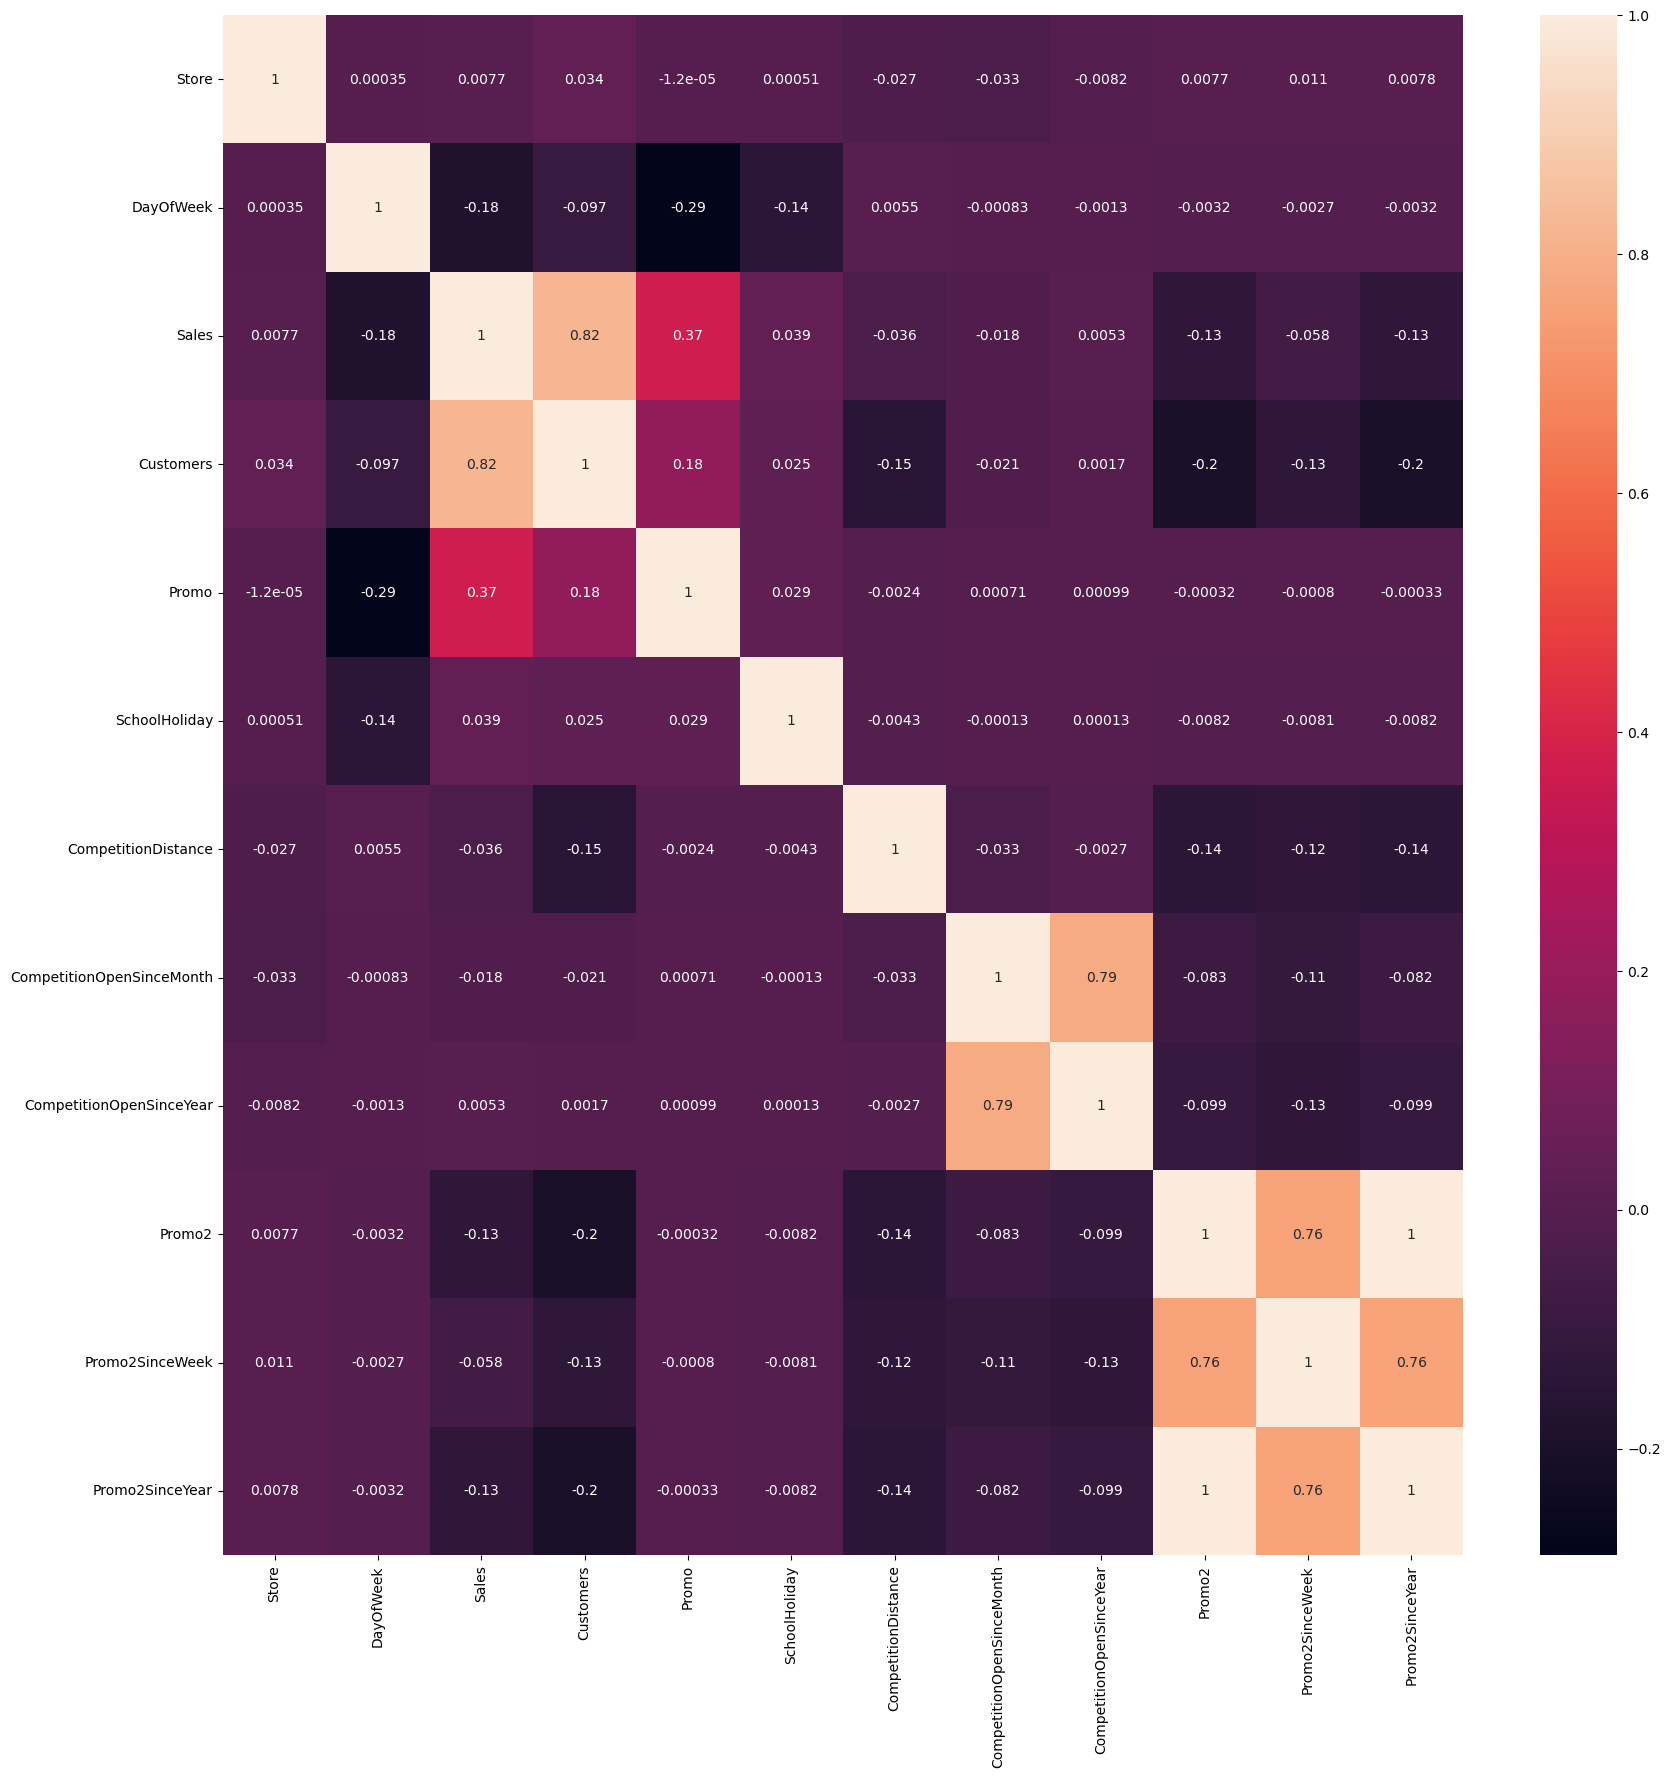

In [51]:
# Create heat Map to check co relation
correlations = sales_train_all_df.corr(numeric_only=True)
f, ax = plt.subplots(figsize = (20, 20))
sns.heatmap(correlations, annot = True)
plt.show()


In [52]:
# Extract Year from Date Column 
# Separate the year from the date column and put it into a separate column 

sales_train_all_df['Year'] = pd.DatetimeIndex(sales_train_all_df['Date']).year
display(sales_train_all_df)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0,2013
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0,2013
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0,2013


In [53]:
# Extract Month and Day Column 
# Same way extract month and day column, add as separate columns
sales_train_all_df['Month'] = pd.DatetimeIndex(sales_train_all_df['Date']).month
sales_train_all_df['Day'] = pd.DatetimeIndex(sales_train_all_df['Date']).day
display(sales_train_all_df)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
844387,682,2,2013-01-01,3375,566,0,a,1,b,a,150.0,9.0,2006.0,0,0.0,0.0,0,2013,1,1
844388,733,2,2013-01-01,10765,2377,0,a,1,b,b,860.0,10.0,1999.0,0,0.0,0.0,0,2013,1,1
844389,769,2,2013-01-01,5035,1248,0,a,1,b,b,840.0,0.0,0.0,1,48.0,2012.0,"Jan,Apr,Jul,Oct",2013,1,1
844390,948,2,2013-01-01,4491,1039,0,a,1,b,b,1430.0,0.0,0.0,0,0.0,0.0,0,2013,1,1


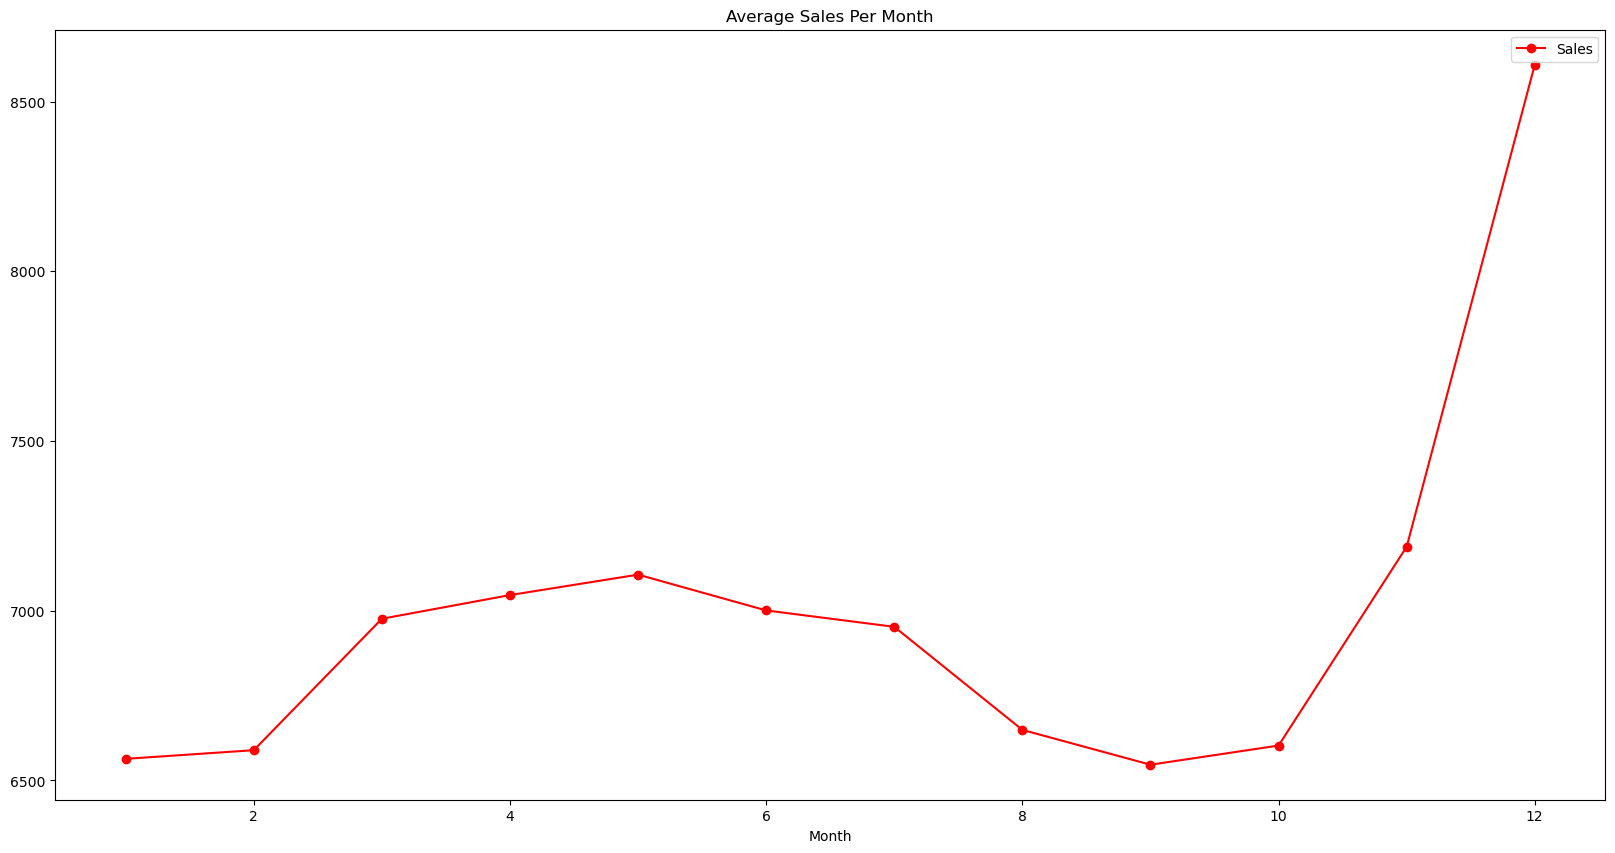

In [54]:
# Average Sales by Month
 # 'groupby' works great by grouping all the data that share the same month column, then obtain the mean of the sales column  
# It looks like sales peak around christmas timeframe

axis = sales_train_all_df.groupby('Month')[['Sales']].mean().plot(figsize = (20,10), marker = 'o', color = 'r')
axis.set_title('Average Sales Per Month')
plt.show()


<Figure size 2000x1000 with 0 Axes>

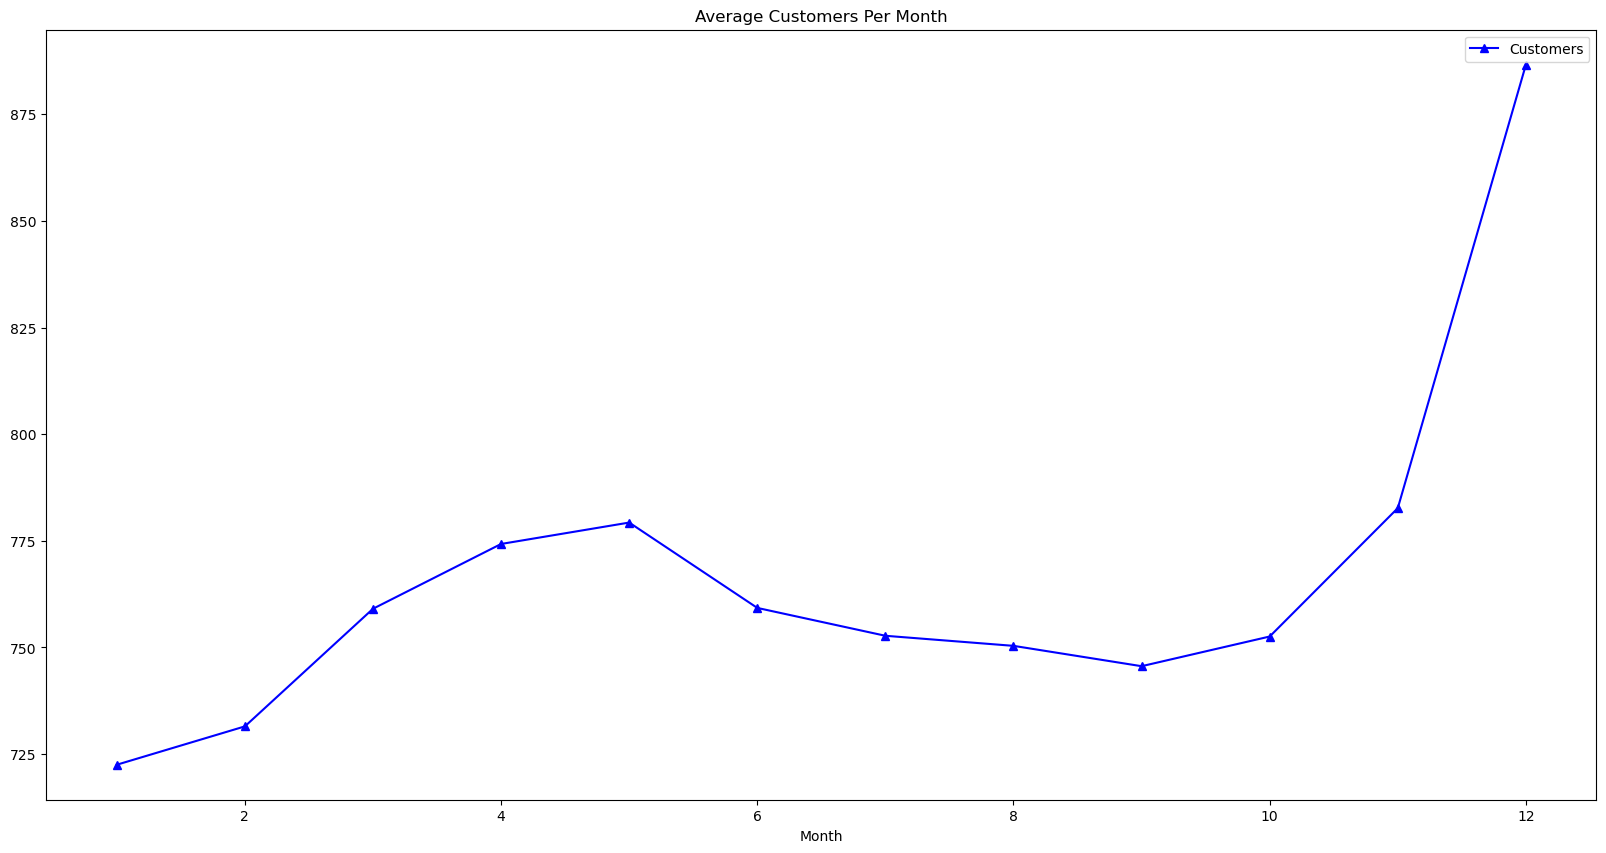

In [55]:
# Average Customer by Month
# It looks like number of customers peak around christmas timeframe

plt.figure()
axis = sales_train_all_df.groupby('Month')[['Customers']].mean().plot(figsize = (20,10), marker = '^', color = 'b')
axis.set_title('Average Customers Per Month')
plt.show()


<Figure size 2000x1000 with 0 Axes>

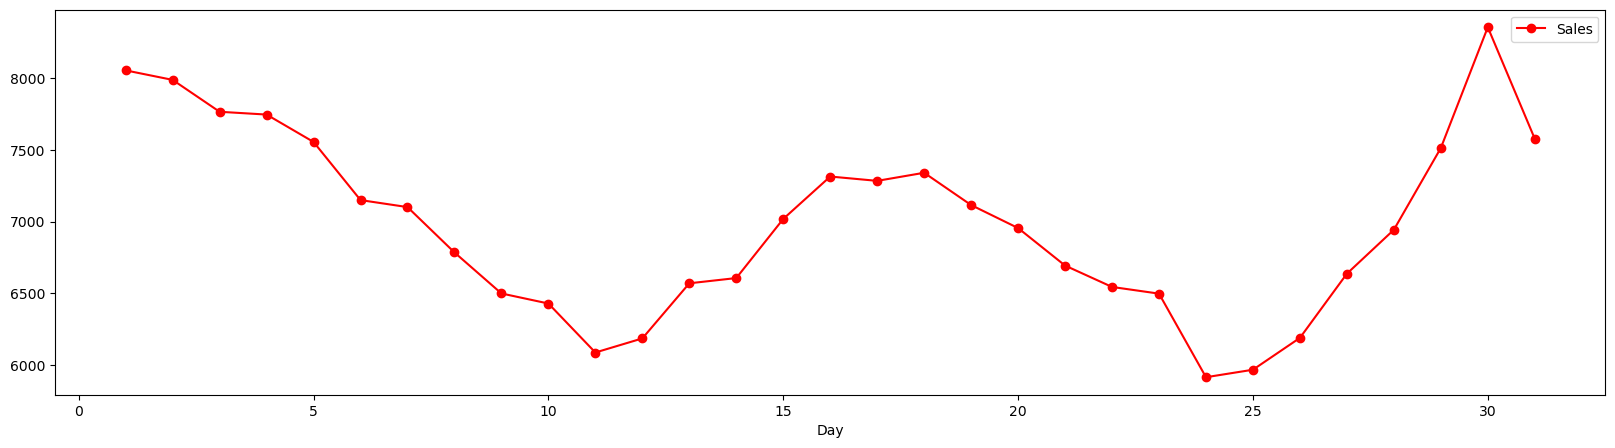

<Figure size 2000x1000 with 0 Axes>

In [56]:
# Display the sales and customers per day of the month instead
# Minimum number of customers are generally around the 24th of the month 
# Most customers and sales are around 30th and 1st of the month
ax = sales_train_all_df.groupby('Day')[['Sales']].mean().plot(figsize = (20,5), marker = 'o', color = 'r')
axis.set_title('Average Sales Per Day')

plt.figure()


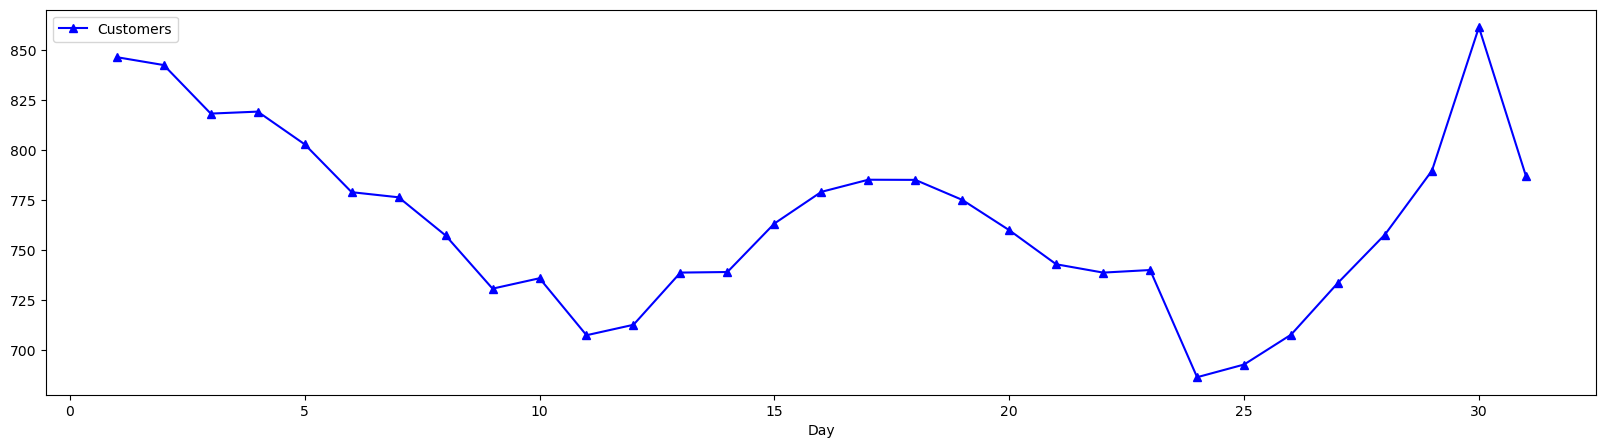

In [57]:
ax = sales_train_all_df.groupby('Day')[['Customers']].mean().plot(figsize = (20,5), marker = '^', color = 'b')
axis.set_title('Average Sales Per Day')
plt.show()


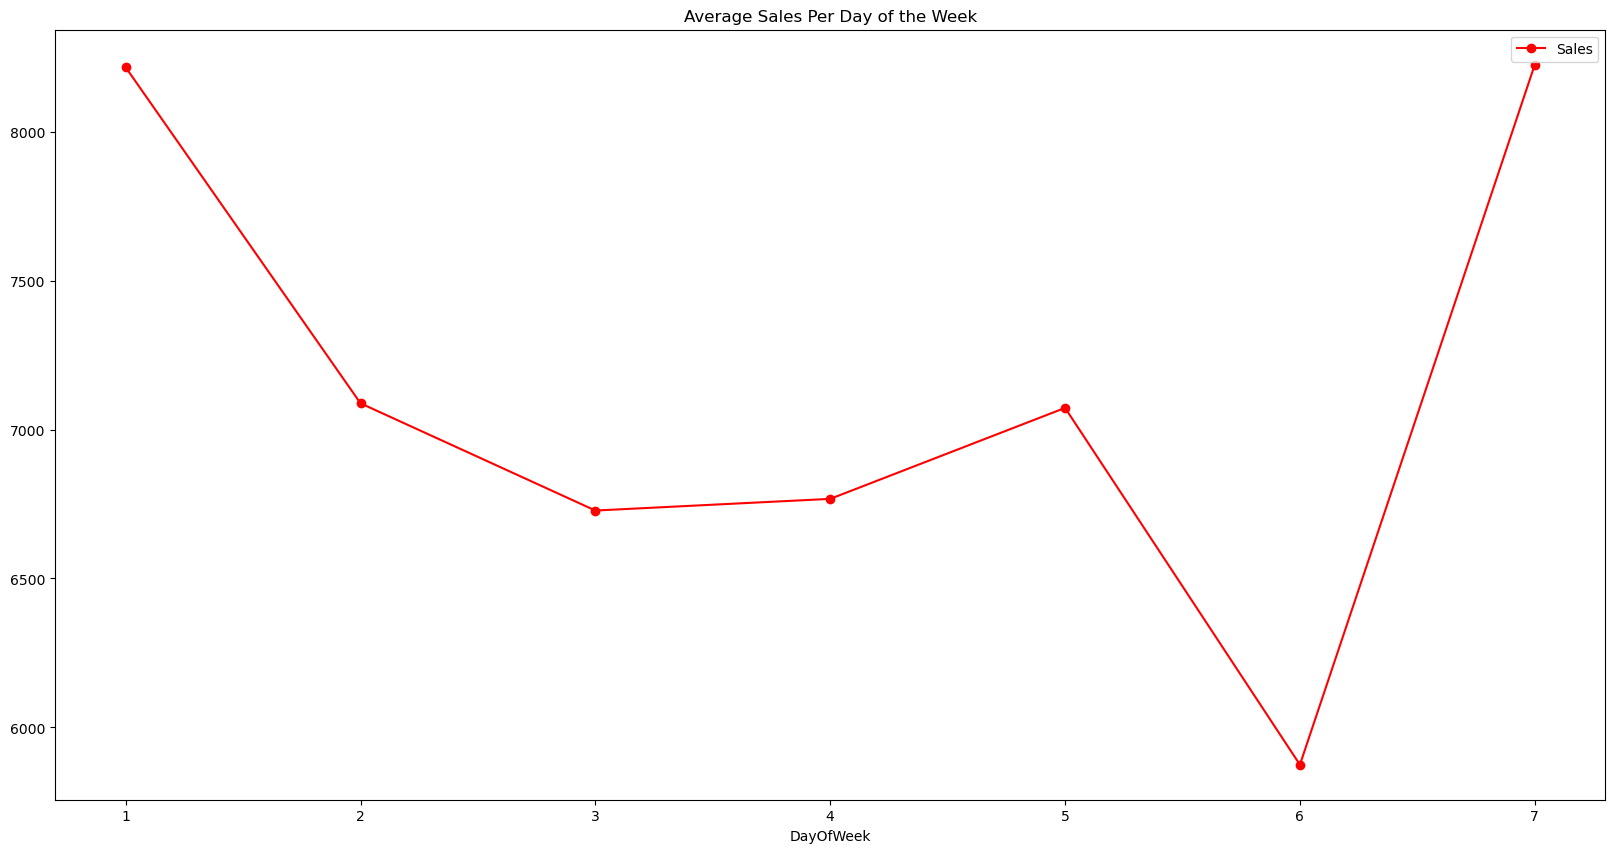

<Figure size 2000x1000 with 0 Axes>

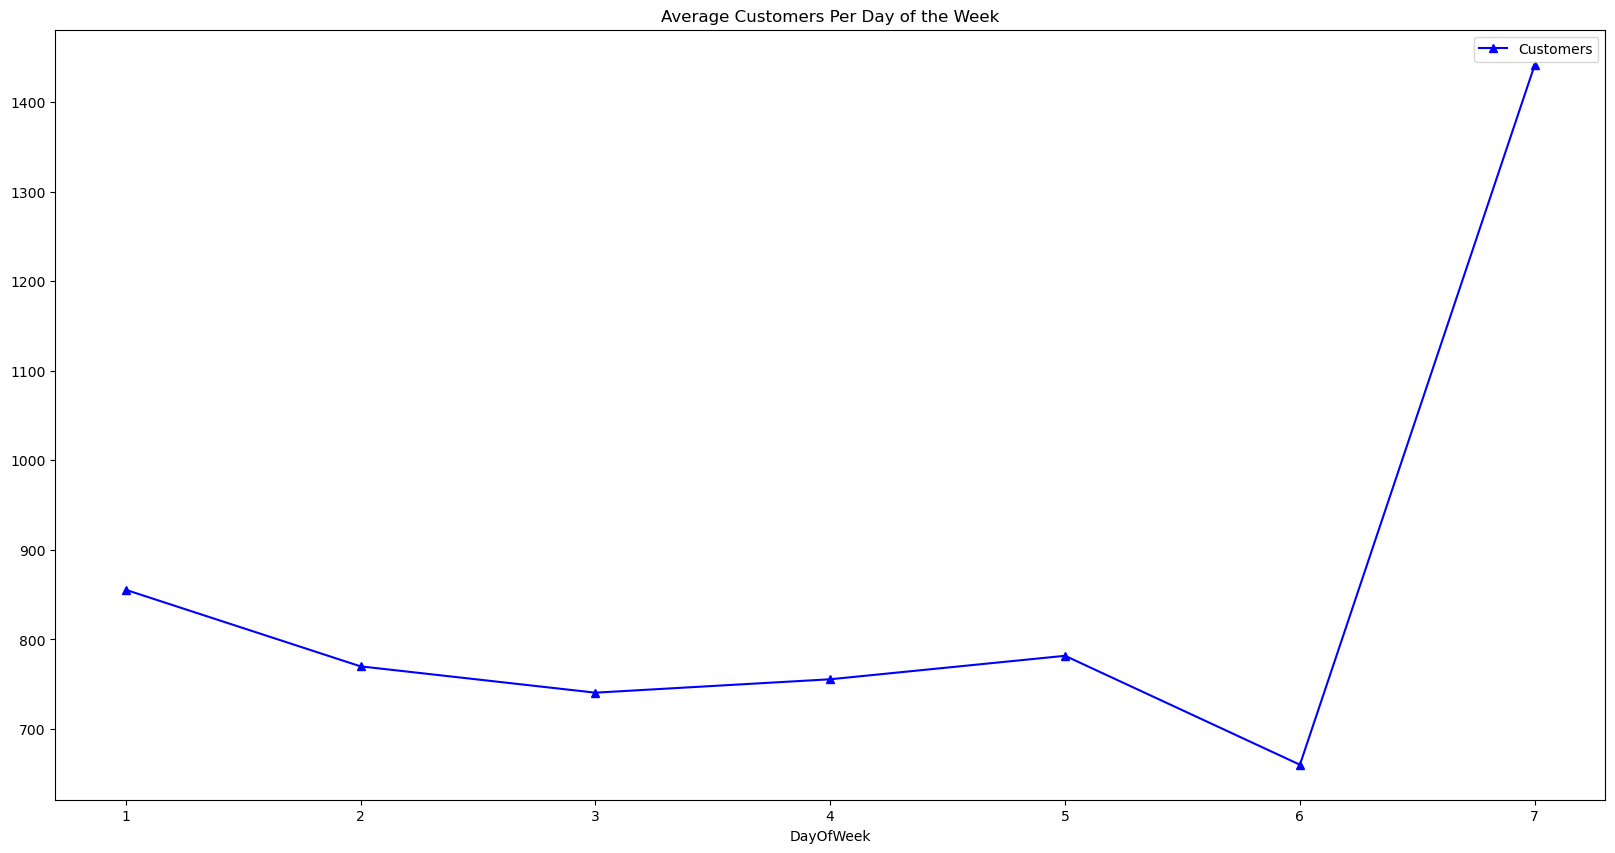

In [58]:
# Display the sales and customers based on day of the week 
# Display the sales and customers for the day of the week (note that 7 = Sunday)

axis = sales_train_all_df.groupby('DayOfWeek')[['Sales']].mean().plot(figsize = (20,10), marker = 'o', color = 'r')
axis.set_title('Average Sales Per Day of the Week')

plt.figure()
axis = sales_train_all_df.groupby('DayOfWeek')[['Customers']].mean().plot(figsize = (20,10), marker = '^', color = 'b')
axis.set_title('Average Customers Per Day of the Week')
plt.show()


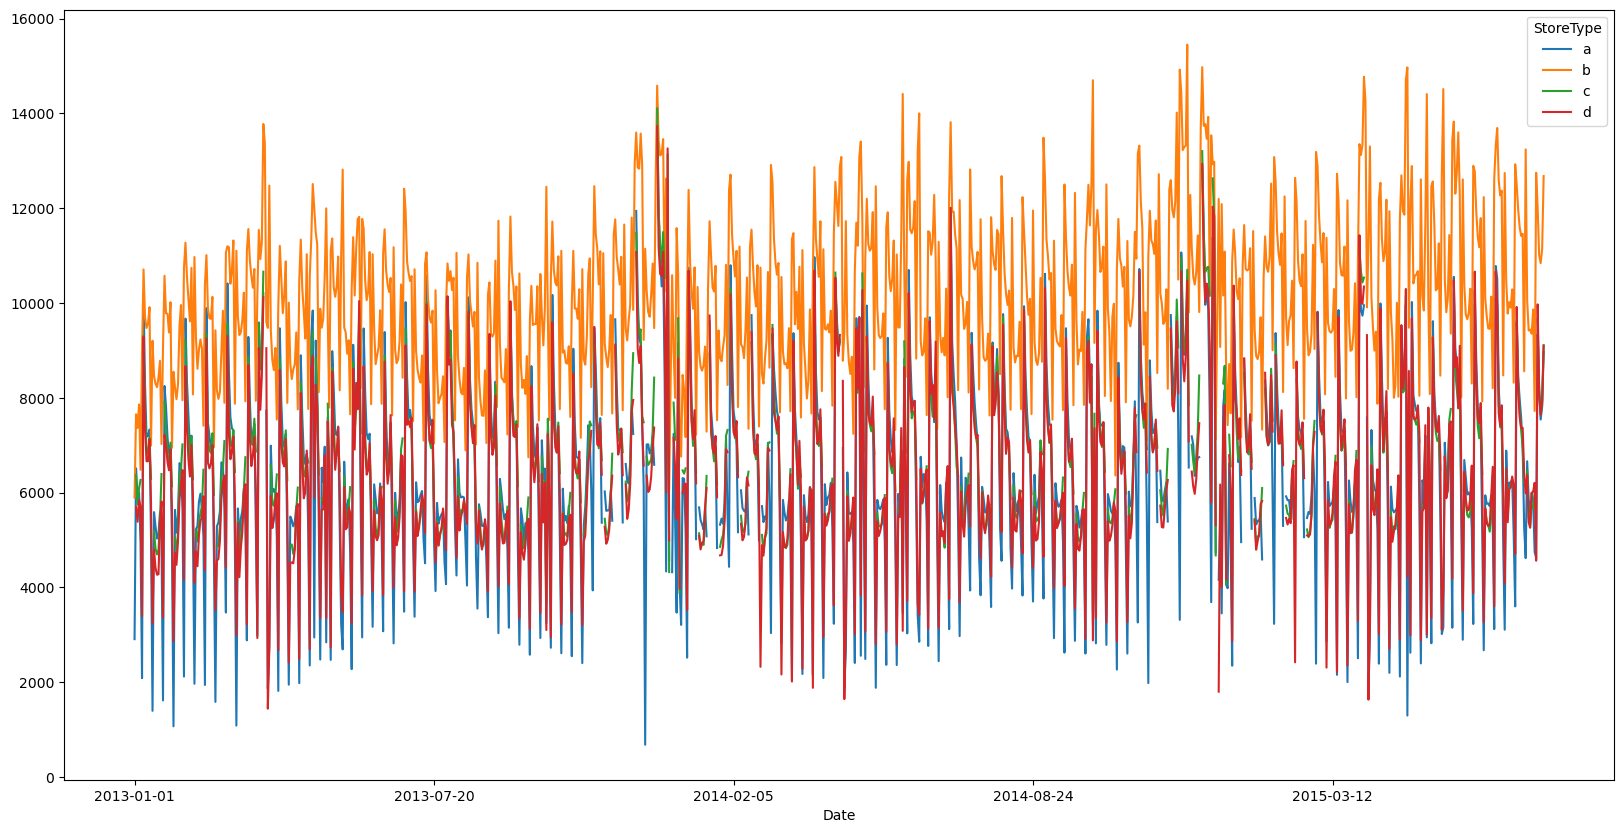

In [61]:
# Average Sales by Store Type by Day (Store Type : a,b,c,d)

fig, ax = plt.subplots(figsize=(20,10))
sales_train_all_df.groupby(['Date','StoreType'])['Sales'].mean().unstack().plot(ax=ax)
plt.show()


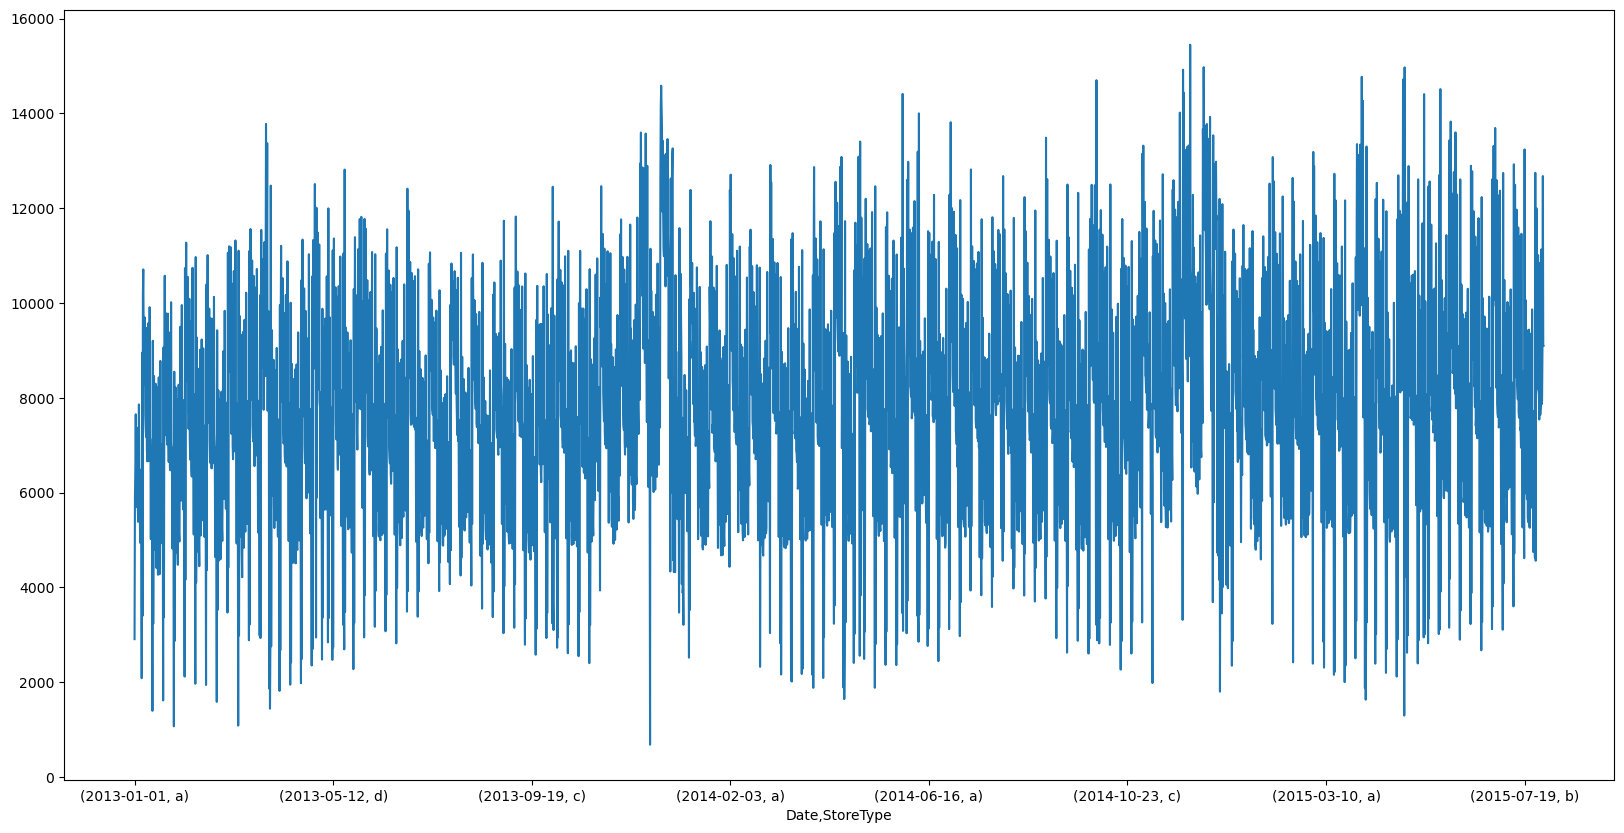

In [63]:
# Average Sales by Store Type by Day without unstack 
#Plot the above graph without unstack 
fig, ax = plt.subplots(figsize=(20,10))
sales_train_all_df.groupby(['Date','StoreType'])['Sales'].mean().plot(ax=ax)
plt.show()


<Axes: xlabel='Promo', ylabel='Customers'>

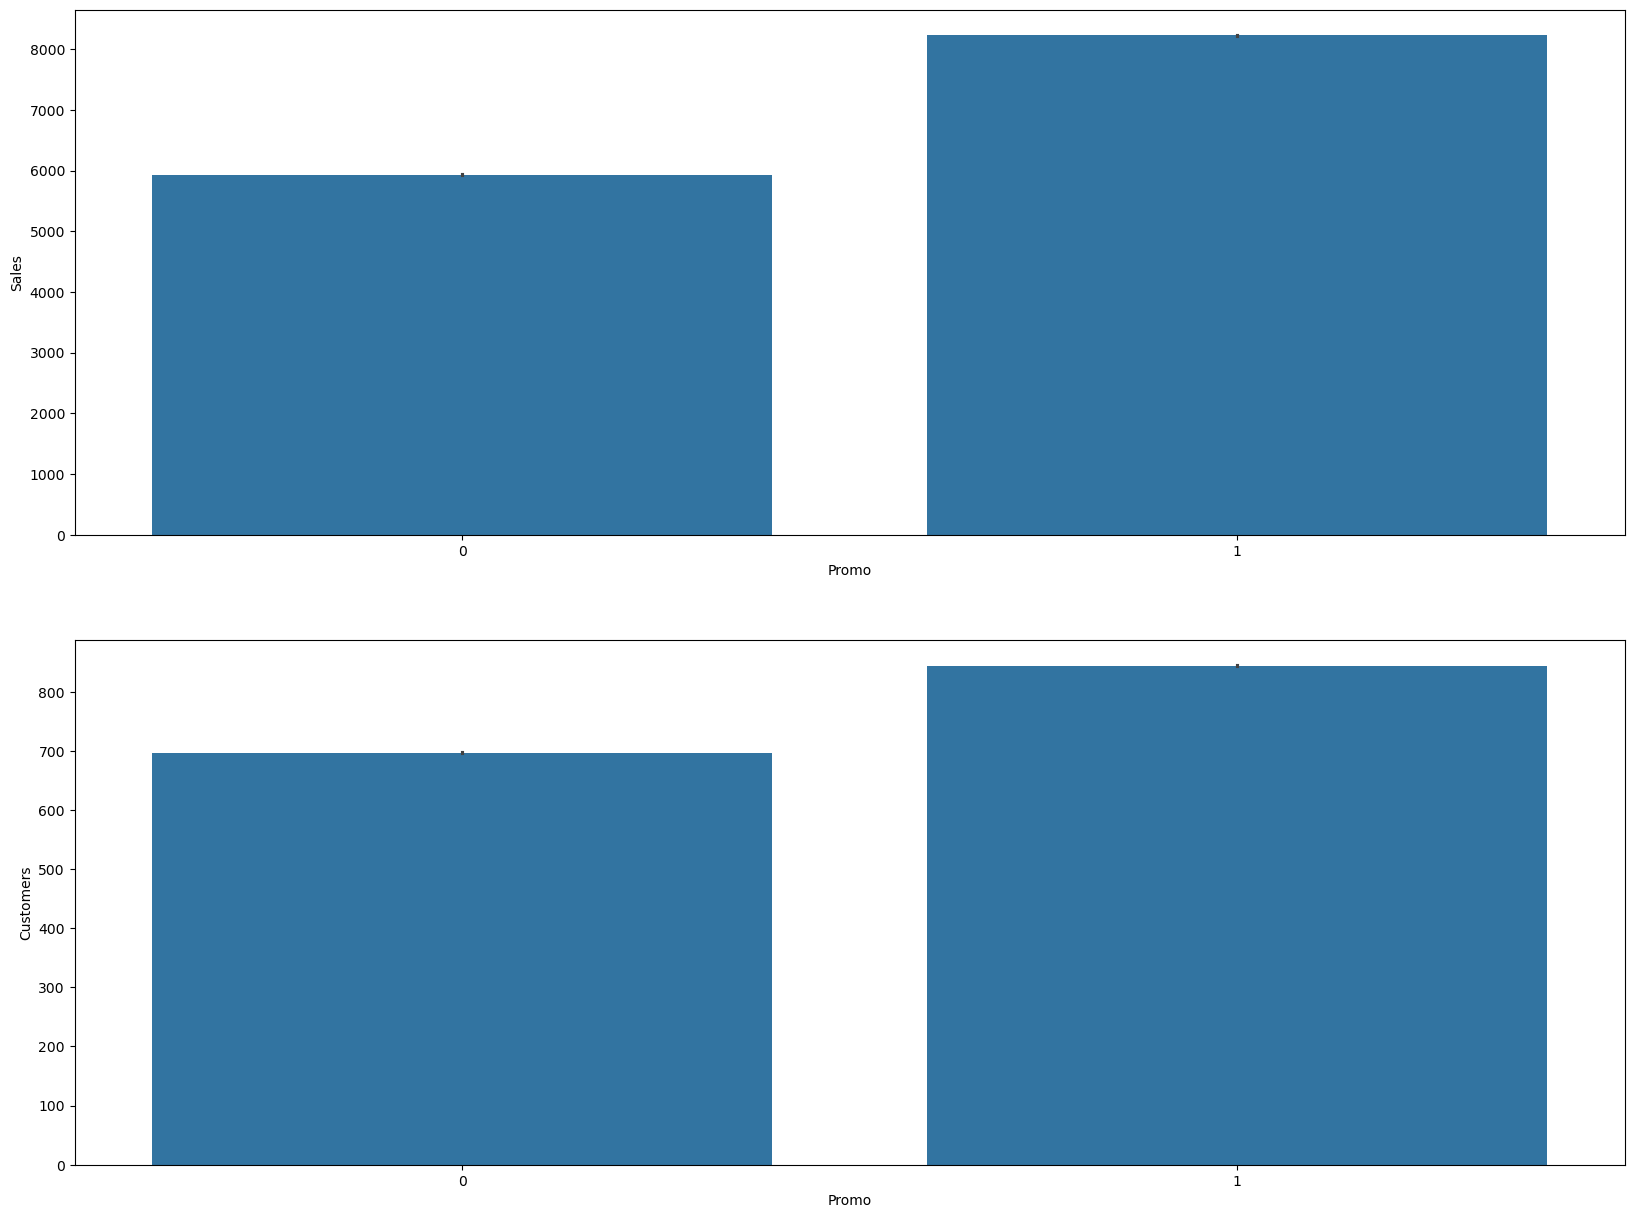

In [65]:
#Graph – Impact of Promo on Sales and Customers – Bar Graph 

plt.figure(figsize=[20,15])

plt.subplot(211)
sns.barplot(x = 'Promo', y = 'Sales', data = sales_train_all_df)

plt.subplot(212)
sns.barplot(x = 'Promo', y = 'Customers', data = sales_train_all_df)


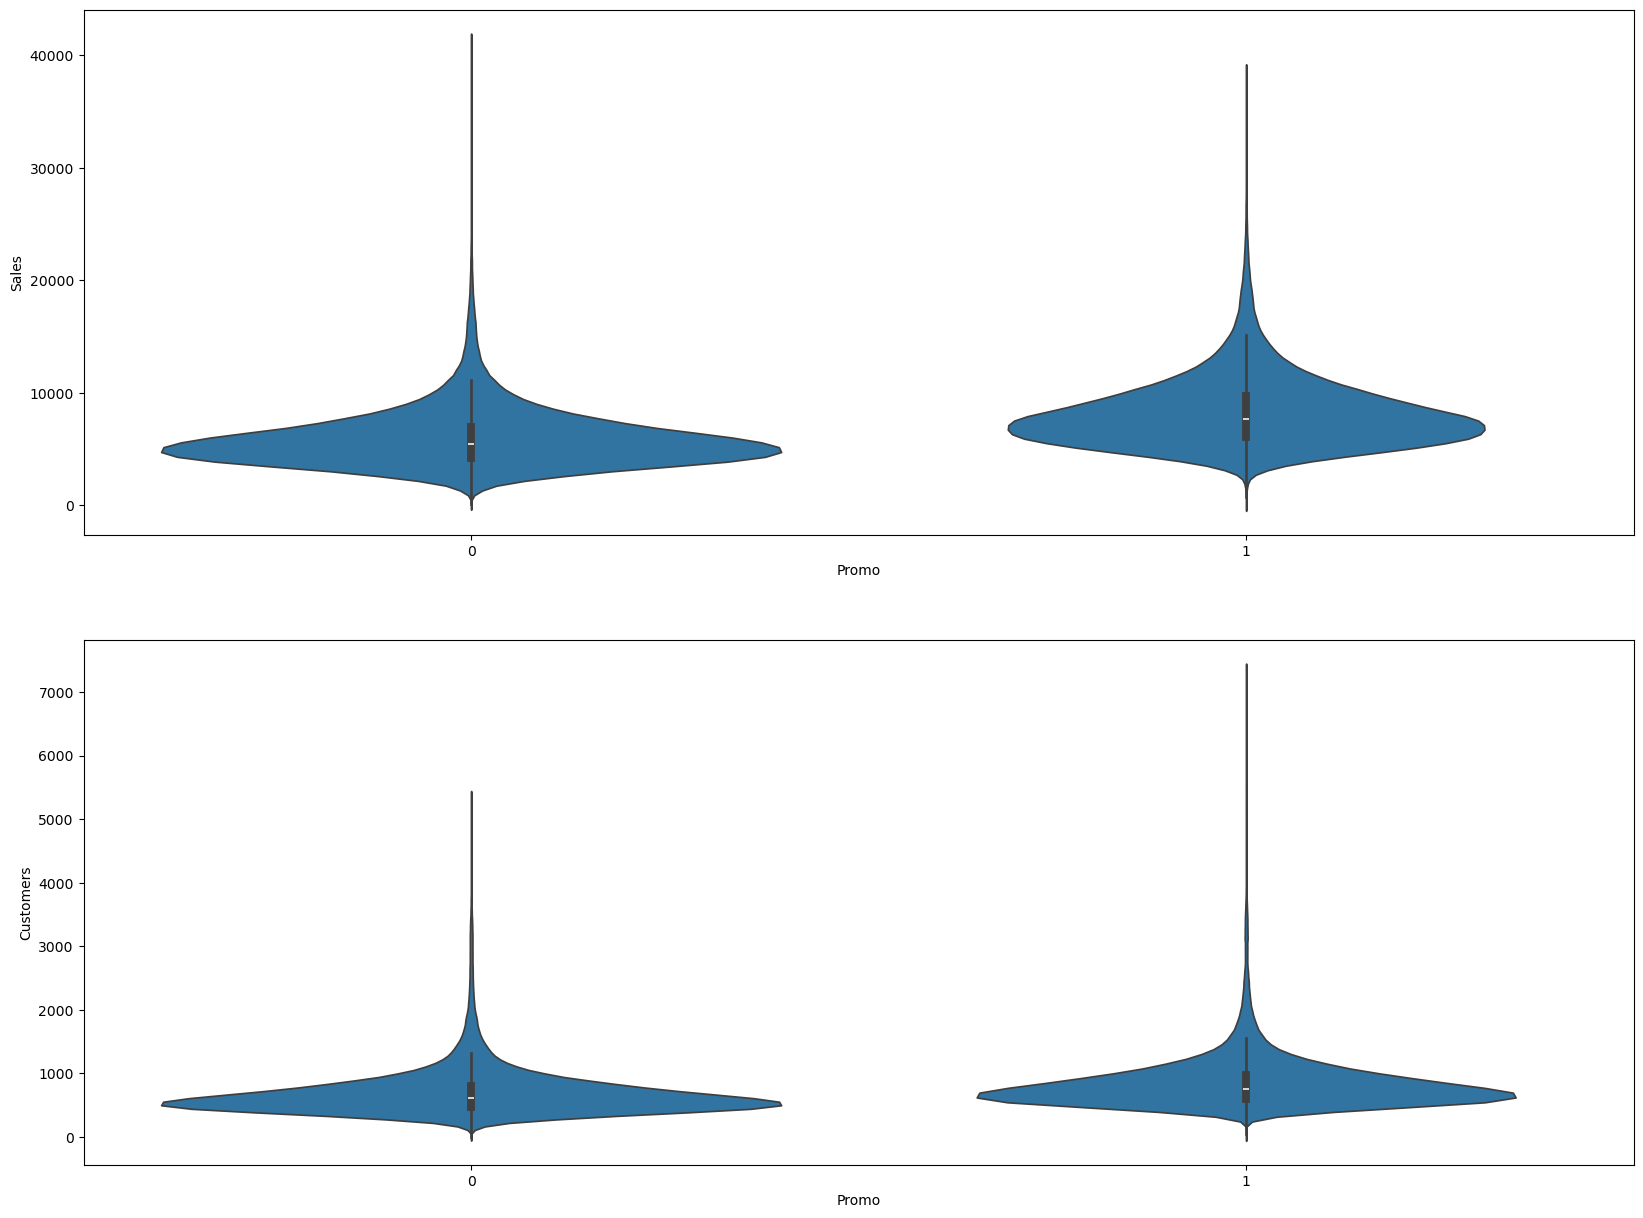

In [67]:
#Graph – Impact of Promo on Sales and Customers – violinplot

plt.figure(figsize=[20,15])

plt.subplot(211)
sns.violinplot(x = 'Promo', y = 'Sales', data = sales_train_all_df)

plt.subplot(212)
sns.violinplot(x = 'Promo', y = 'Customers', data = sales_train_all_df)
plt.show()


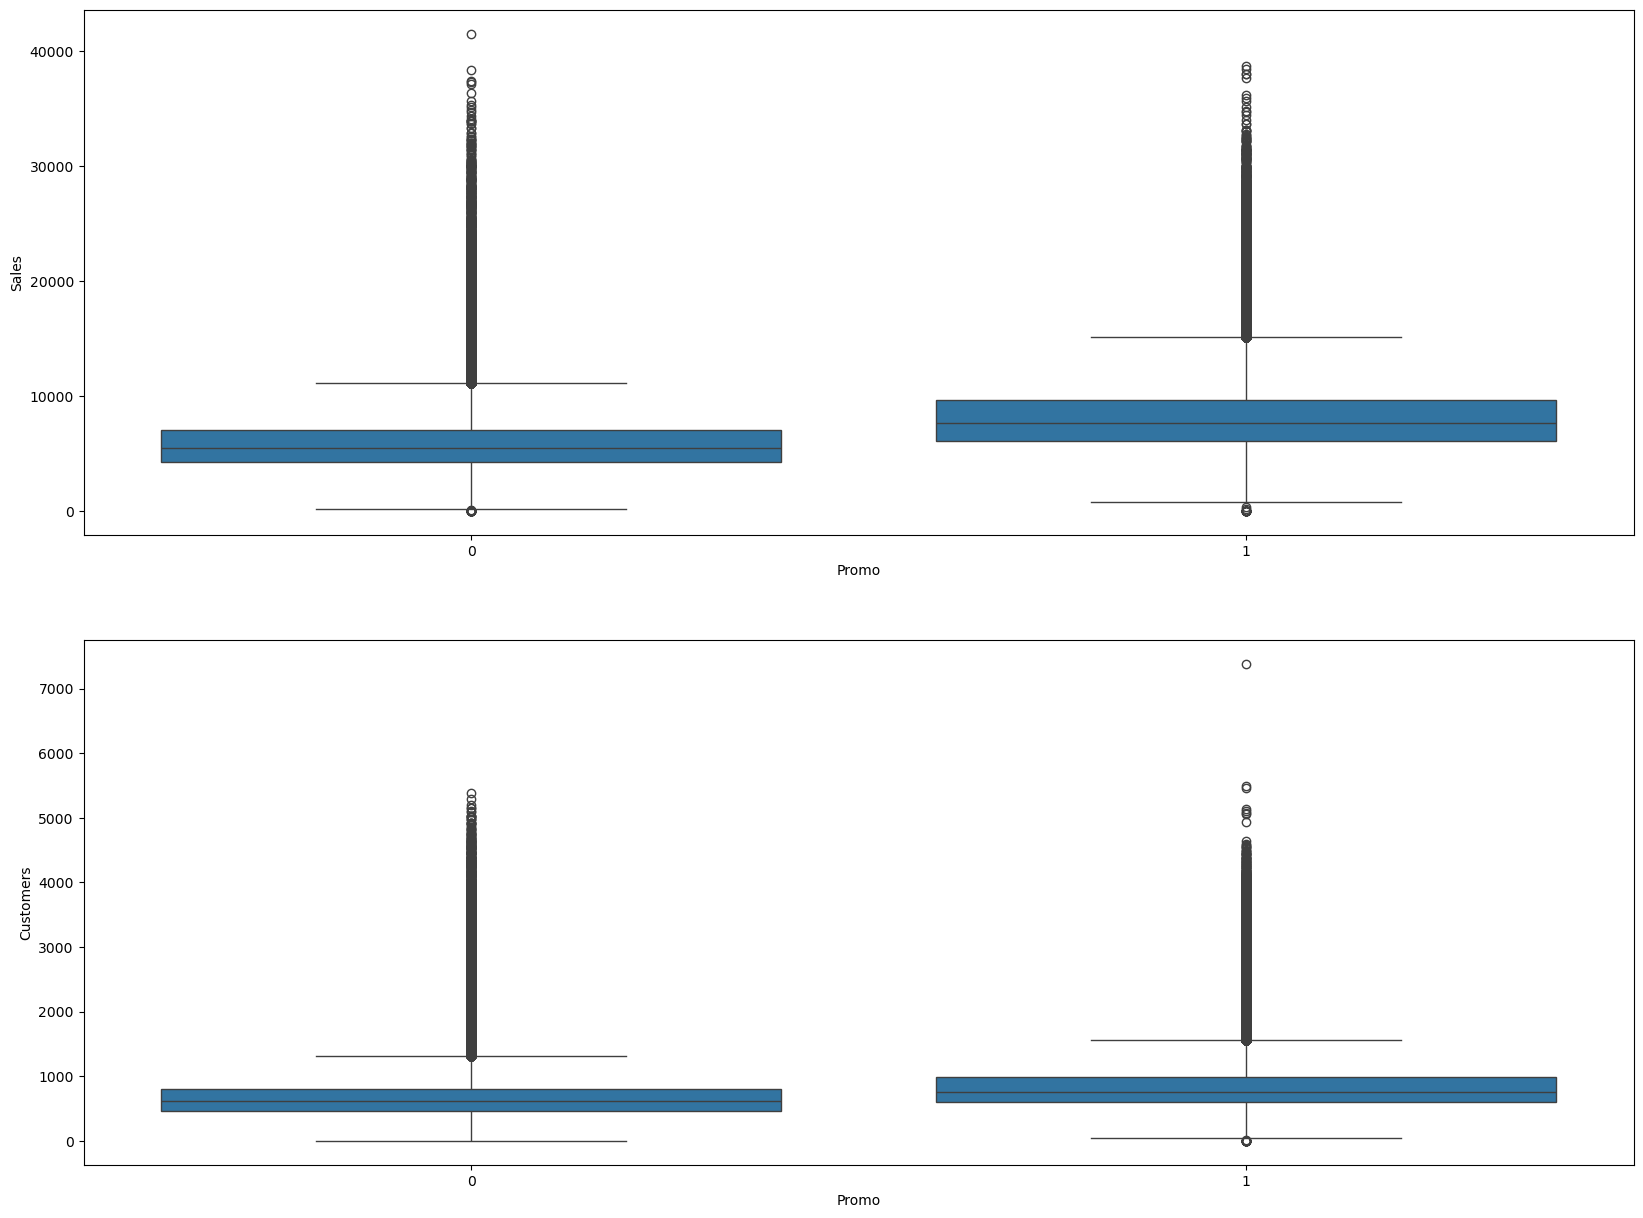

In [69]:
#Graph – Impact of Promo on Sales and Customers – Boxplot

plt.figure(figsize=[20,15])

plt.subplot(211)
sns.boxplot(x = 'Promo', y = 'Sales', data = sales_train_all_df)

plt.subplot(212)
sns.boxplot(x = 'Promo', y = 'Customers', data = sales_train_all_df)
plt.show()


In [72]:
#TRAIN THE MODEL

#Import Library 

!pip install prophet
from prophet import Prophet


Importing plotly failed. Interactive plots will not work.


In [73]:
#Create the Function for Forecasting, prediction based on the specified store ie store id 

def sales_prediction(Store_ID, sales_df, periods):
    # Function that takes in the data frame, storeID, and number of future period forecast
    # The function then generates date/sales columns in Prophet format ie Rename Date column to ds and Sales to y
    # The function then makes time series predictions
    
    # Step 1: Select data for the given Store_ID
    sales_df = sales_df[sales_df['Store'] == Store_ID]
    
    # Step 2: Create the data frame by selecting Date and Sales, rename to Prophet format
    sales_df = sales_df[['Date', 'Sales']].rename(columns={'Date': 'ds', 'Sales': 'y'})
    
    # Step 3: Create and fit the Prophet model
    model = Prophet()
    model.fit(sales_df)
    
    # Step 4: Create future dataframe for the specified number of periods
    future = model.make_future_dataframe(periods=periods)
    
    # Step 5: Make predictions
    forecast = model.predict(future)
    
    # Step 6: Plot the forecast
    figure = model.plot(forecast, xlabel='Date', ylabel='Sales')
    
    return forecast


19:07:09 - cmdstanpy - INFO - Chain [1] start processing
19:07:11 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2013-01-02,5199.103190,4147.065567,6200.941439,5199.103190,5199.103190,-44.920975,-44.920975,-44.920975,-203.566455,-203.566455,-203.566455,158.645480,158.645480,158.645480,0.0,0.0,0.0,5154.182214
1,2013-01-03,5199.853582,3996.826678,6126.854916,5199.853582,5199.853582,-93.789302,-93.789302,-93.789302,-183.601749,-183.601749,-183.601749,89.812447,89.812447,89.812447,0.0,0.0,0.0,5106.064280
2,2013-01-04,5200.603975,4242.049762,6432.835780,5200.603975,5200.603975,89.459259,89.459259,89.459259,65.553035,65.553035,65.553035,23.906224,23.906224,23.906224,0.0,0.0,0.0,5290.063234
3,2013-01-05,5201.354367,3396.626225,5443.639030,5201.354367,5201.354367,-757.966081,-757.966081,-757.966081,-719.517399,-719.517399,-719.517399,-38.448683,-38.448683,-38.448683,0.0,0.0,0.0,4443.388286
4,2013-01-07,5202.855152,5002.757307,7173.648786,5202.855152,5202.855152,862.187442,862.187442,862.187442,1012.596089,1012.596089,1012.596089,-150.408647,-150.408647,-150.408647,0.0,0.0,0.0,6065.042594
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
839,2015-09-25,5952.501877,4987.766360,6998.410406,5952.488106,5952.516407,67.062659,67.062659,67.062659,65.553035,65.553035,65.553035,1.509624,1.509624,1.509624,0.0,0.0,0.0,6019.564537
840,2015-09-26,5953.259389,4175.204614,6293.845267,5953.245229,5953.274415,-699.353132,-699.353132,-699.353132,-719.517399,-719.517399,-719.517399,20.164266,20.164266,20.164266,0.0,0.0,0.0,5253.906256
841,2015-09-27,5954.016900,4723.626401,6867.181343,5954.002287,5954.032517,-159.848332,-159.848332,-159.848332,-194.744472,-194.744472,-194.744472,34.896140,34.896140,34.896140,0.0,0.0,0.0,5794.168568
842,2015-09-28,5954.774412,5993.223797,8089.424612,5954.759130,5954.790543,1057.996012,1057.996012,1057.996012,1012.596089,1012.596089,1012.596089,45.399923,45.399923,45.399923,0.0,0.0,0.0,7012.770424


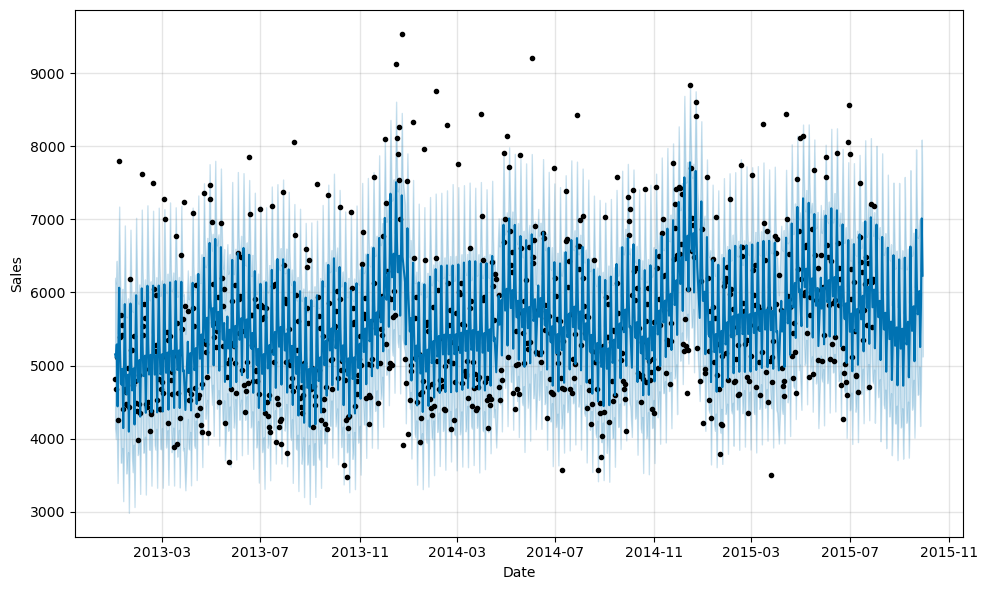

In [74]:
# Call the function to predict for next 60 periods 
sales_prediction(10, sales_train_all_df, 60)


In [75]:
# Updated Function to predict on Holidays- Included one more input holidays 

def sales_prediction(Store_ID, sales_df, holidays, periods):
  # Function that takes in the storeID and returns two date/sales columns in Prophet format
  # Format data to fit prophet 

  sales_df = sales_df[ sales_df['Store'] == Store_ID ]
  sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales':'y'})
  sales_df = sales_df.sort_values('ds')
  
  model    = Prophet(holidays = holidays)
  model.fit(sales_df)
  future   = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure   = model.plot(forecast, xlabel='Date', ylabel='Sales')
  figure2  = model.plot_components(forecast)


In [76]:
# Get all the dates related to school holidays 
school_holidays = sales_train_all_df[sales_train_all_df['SchoolHoliday'] == 1].loc[:, 'Date'].values
display (school_holidays.shape)


(163457,)

In [77]:
# Print school holidays 
display(school_holidays)


array(['2015-07-31', '2015-07-31', '2015-07-31', ..., '2013-01-01',
       '2013-01-01', '2013-01-01'], shape=(163457,), dtype=object)

In [78]:
# Get all the dates related to state holidays 
state_holidays = sales_train_all_df [ (sales_train_all_df['StateHoliday'] == 'a') | (sales_train_all_df['StateHoliday'] == 'b') | (sales_train_all_df['StateHoliday'] == 'c')  ].loc[:, 'Date'].values
display (state_holidays.shape)


(910,)

In [79]:
# Print State Holidays 
state_holidays = pd.DataFrame({'ds': pd.to_datetime(state_holidays),
                               'holiday': 'state_holiday'})
display(state_holidays )


,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
905,2013-01-01,state_holiday
906,2013-01-01,state_holiday
907,2013-01-01,state_holiday
908,2013-01-01,state_holiday


In [80]:
# Print School Holidays 

school_holidays = pd.DataFrame({'ds': pd.to_datetime(school_holidays),
                                'holiday': 'school_holiday'})
display (school_holidays)


,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


In [81]:
# Display School and State Holidays 

# Concat state and scholl holidays
school_state_holidays = pd.concat((state_holidays, school_holidays))
display (school_state_holidays)


,ds,holiday
0,2015-06-04,state_holiday
1,2015-06-04,state_holiday
2,2015-06-04,state_holiday
3,2015-06-04,state_holiday
4,2015-06-04,state_holiday
...,...,...
163452,2013-01-01,school_holiday
163453,2013-01-01,school_holiday
163454,2013-01-01,school_holiday
163455,2013-01-01,school_holiday


19:10:30 - cmdstanpy - INFO - Chain [1] start processing
19:10:30 - cmdstanpy - INFO - Chain [1] done processing


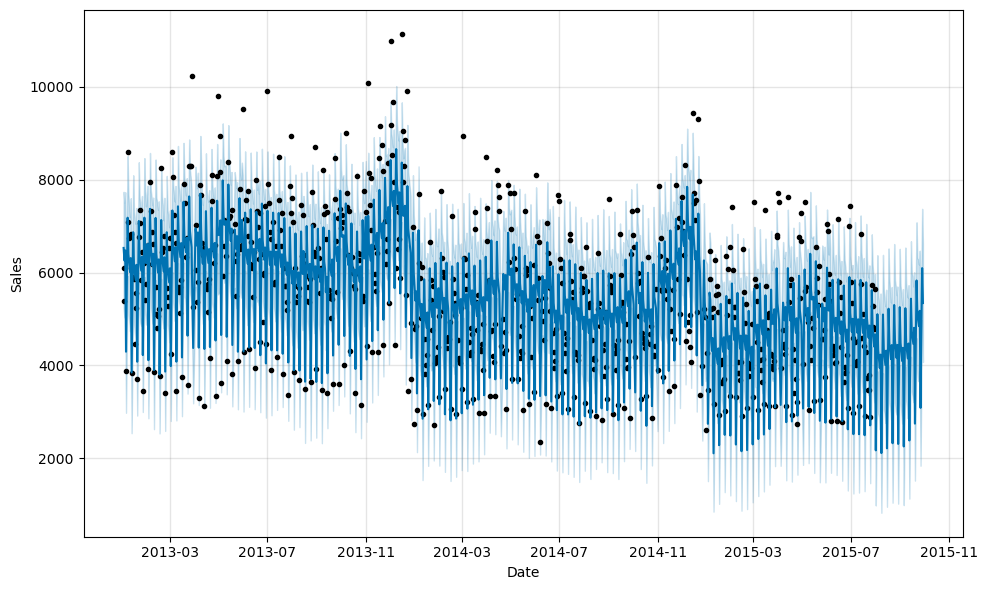

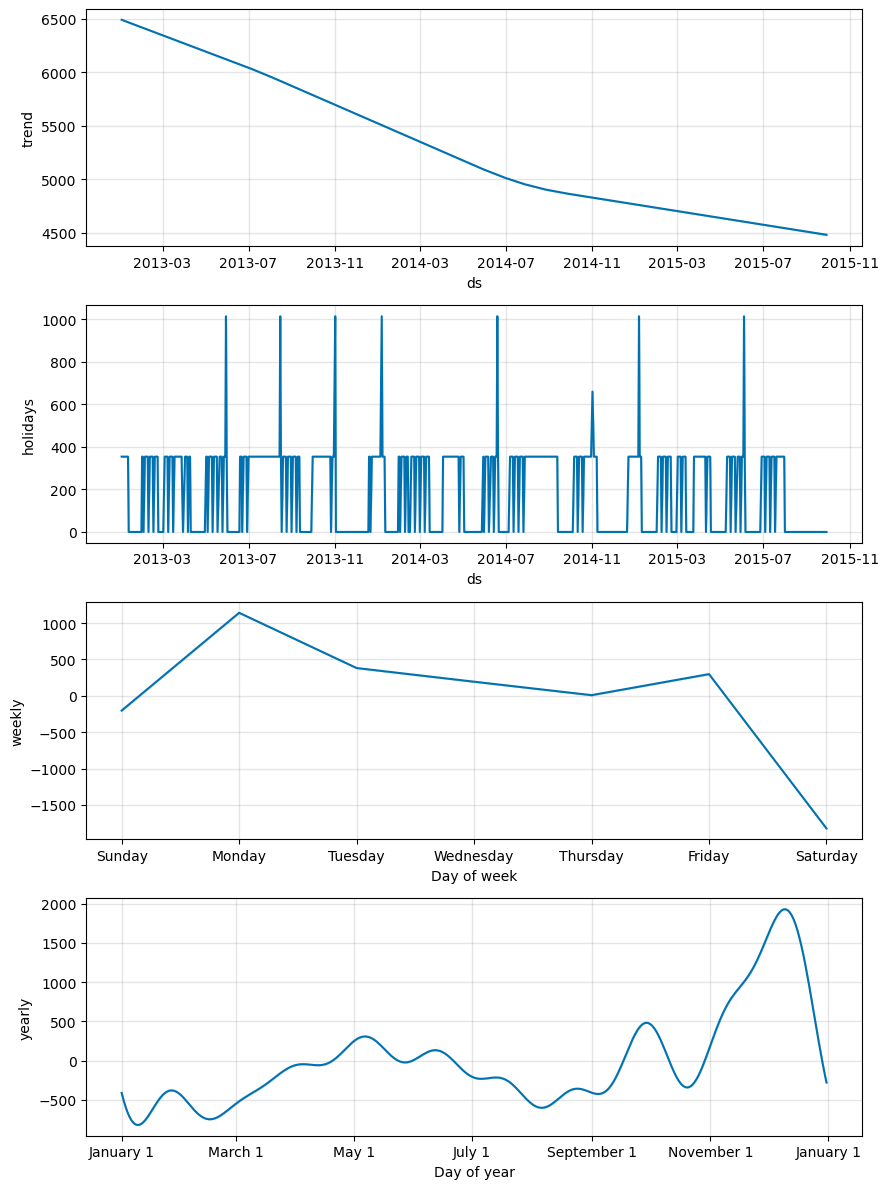

In [82]:
# Sales Prediction for 60 Day for School and state holidays 
sales_prediction(6, sales_train_all_df, school_state_holidays, 60)
